# Predicción del Abandono de Clientes

#### Comprensión del Negocio
Este proyecto desarrolla modelos de clasificación para identificar clientes con alta probabilidad de abandonar el servicio.

#### Hipótesis
**Hipótesis nula (H₀):**
No existe una relación significativa entre la antigüedad del cliente y la tasa de deserción en la empresa de telecomunicaciones.

**Hipótesis alternativa (Hₐ):**
Existe una relación significativa entre la antigüedad del cliente y la tasa de deserción en la empresa de telecomunicaciones.

#### Preguntas de Investigación
1. ¿Cómo se relaciona la antigüedad del cliente con la tasa de deserción? ¿Los clientes con mayor tiempo de permanencia tienen una mayor probabilidad de continuar con la empresa, mientras que los clientes más recientes presentan una mayor tendencia al abandono?
2. ¿Existe una relación entre el monto total facturado (*Total Charges*) y la tasa de deserción? ¿Los clientes con mayores cargos acumulados presentan un comportamiento de abandono diferente al de aquellos con menores cargos?
3. ¿Cuál es el impacto del tipo de contrato sobre la tasa de deserción? ¿Los clientes con contratos de largo plazo presentan tasas de abandono significativamente menores que aquellos con contratos de corto plazo?
4. ¿Existen diferencias significativas en el comportamiento de deserción entre los clientes que cuentan con protección para dispositivos (*Device Protection*) y aquellos que no disponen de este servicio?
5. ¿Cuál es la relación entre la disponibilidad de soporte técnico (*Tech Support*) y la tasa de deserción? ¿Los clientes que tienen acceso a soporte técnico presentan una mayor probabilidad de permanecer en la empresa?
6. ¿Los servicios de *streaming* influyen en la deserción de clientes? ¿Los clientes que cuentan con servicios como **StreamingTV** y **StreamingMovies** tienen una mayor probabilidad de permanecer en la empresa?
7. ¿Cómo influye el método de pago en la tasa de deserción? ¿Los clientes que utilizan determinados métodos de pago presentan una mayor propensión al abandono que otros?

# 1. Importar y cargar librerias

## 1.1. Importar librerías

In [ ]:
#import sys
#!"{sys.executable}" -m pip install pyodbc python-dotenv pandas openpyxl numpy seaborn matplotlib plotly statsmodels scipy scikit-learn imbalanced-learn xgboost joblib

## 1.2. Cargar librerías

In [693]:
# Conexión a bases de datos
import pyodbc 
from dotenv import dotenv_values
import warnings 
warnings.filterwarnings('ignore')

# Manipulación y procesamiento de datos
import pandas as pd
pd.set_option('display.max_columns', None)
import openpyxl
import numpy as np

# Visualización de datos (Matplotlib, Plotly, Seaborn, etc.)
import seaborn as sns
sns.set_style('whitegrid')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.colors as colors
from plotly.subplots import make_subplots

# Análisis Exploratorio de Datos (EDA) (pandas-profiling, etc.)
from statsmodels.genmod.families import Binomial
from scipy.stats import pointbiserialr
import scipy.stats as stats
#from scipy import stats

# Procesamiento y transformación de variables (herramientas de procesamiento de Scikit-learn, etc.)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import mutual_info_score
from sklearn.compose import make_column_transformer
from imblearn.over_sampling import SMOTE

# Aprendizaje Automático (Machine Learning) (estimadores de Scikit-learn, CatBoost, LightGBM, etc.)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import KFold, cross_val_score

# Optimización de hiperparámetros (búsqueda de hiperparámetros, validación cruzada (cross-validation) con Scikit-learn, etc.)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix

# Otras librerías y paquetes
from pathlib import Path
import os, joblib
from joblib import load

# 2. Cargar y preparar las bases de datos

**Descripción de variables de las bases de datos**
| **Nombre de la Variable** | **Descripción** | **Tipo de Dato** |
|---------------------------|-----------------|------------------|
| `customerID` | Contiene el identificador único del cliente. | Categórico |
| `gender` | Indica si el cliente es mujer o hombre. | Categórico |
| `SeniorCitizen` | Indica si el cliente es un adulto mayor o no (1 = Sí, 0 = No). | Numérico (entero) |
| `Partner` | Indica si el cliente tiene pareja (Sí, No). | Categórico |
| `Dependents` | Indica si el cliente tiene dependientes (Sí, No). | Categórico |
| `tenure` | Número de meses que el cliente ha permanecido en la empresa. | Numérico (entero) |
| `PhoneService` | Indica si el cliente cuenta con servicio telefónico (Sí, No). | Categórico |
| `MultipleLines` | Indica si el cliente tiene múltiples líneas telefónicas (Sí, No, Sin servicio telefónico). | Categórico |
| `InternetService` | Tipo de servicio de Internet del cliente (DSL, Fibra óptica, Sin servicio). | Categórico |
| `OnlineSecurity` | Indica si el cliente cuenta con servicio de seguridad en línea (Sí, No, Sin servicio de Internet). | Categórico |
| `OnlineBackup` | Indica si el cliente cuenta con servicio de respaldo en línea (Sí, No, Sin servicio de Internet). | Categórico |
| `DeviceProtection` | Indica si el cliente cuenta con servicio de protección de dispositivos (Sí, No, Sin servicio de Internet). | Categórico |
| `TechSupport` | Indica si el cliente cuenta con soporte técnico (Sí, No, Sin servicio de Internet). | Categórico |
| `StreamingTV` | Indica si el cliente cuenta con servicio de televisión por streaming (Sí, No, Sin servicio de Internet). | Categórico |
| `StreamingMovies` | Indica si el cliente cuenta con servicio de películas por streaming (Sí, No, Sin servicio de Internet). | Categórico |
| `Contract` | Tipo de contrato del cliente (Mensual, Un año, Dos años). | Categórico |
| `PaperlessBilling` | Indica si el cliente utiliza facturación electrónica (Sí, No). | Categórico |
| `PaymentMethod` | Método de pago del cliente (Cheque electrónico, Cheque enviado por correo, Transferencia bancaria, Tarjeta de crédito). | Categórico |
| `MonthlyCharges` | Monto cobrado mensualmente al cliente. | Numérico (decimal) |
| `TotalCharges` | Monto total cobrado al cliente. | Objeto (`object`) |
| `Churn` | Indica si el cliente abandonó el servicio o no (Sí, No). | Categórico |

## 2.1. Datos de entrenamiento  (Train Data)

### 2.1.1. Cargar y limpiar la base "LP1_Telco_churn_first_3000.csv"

In [694]:
data_1 = pd.read_csv(r"data\raw\LP1_Telco_churn_first_3000.csv")
data_1.info()
data_1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        3000 non-null   object 
 1   gender            3000 non-null   object 
 2   SeniorCitizen     3000 non-null   bool   
 3   Partner           3000 non-null   bool   
 4   Dependents        3000 non-null   bool   
 5   tenure            3000 non-null   int64  
 6   PhoneService      3000 non-null   bool   
 7   MultipleLines     2731 non-null   object 
 8   InternetService   3000 non-null   object 
 9   OnlineSecurity    2349 non-null   object 
 10  OnlineBackup      2349 non-null   object 
 11  DeviceProtection  2349 non-null   object 
 12  TechSupport       2349 non-null   object 
 13  StreamingTV       2349 non-null   object 
 14  StreamingMovies   2349 non-null   object 
 15  Contract          3000 non-null   object 
 16  PaperlessBilling  3000 non-null   bool   


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,False,True,False,1,False,NaN,DSL,False,True,False,False,False,False,Month-to-month,True,Electronic check,29.850000,29.850000,False
1,5575-GNVDE,Male,False,False,False,34,True,False,DSL,True,False,True,False,False,False,One year,False,Mailed check,56.950001,1889.500000,False
2,3668-QPYBK,Male,False,False,False,2,True,False,DSL,True,True,False,False,False,False,Month-to-month,True,Mailed check,53.849998,108.150002,True
3,7795-CFOCW,Male,False,False,False,45,False,NaN,DSL,True,False,True,True,False,False,One year,False,Bank transfer (automatic),42.299999,1840.750000,False
4,9237-HQITU,Female,False,False,False,2,True,False,Fiber optic,False,False,False,False,False,False,Month-to-month,True,Electronic check,70.699997,151.649994,True


In [695]:
# Convertir las columnas de tipo booleano (bool) al tipo de dato objeto (object)
bool_to_obj = {'SeniorCitizen': object,
               'Partner': object,
               'Dependents': object, 
               'PhoneService': object,
               'PaperlessBilling': object}
data_1 = data_1.astype(bool_to_obj)

In [696]:
# Reemplazar los valores True y False por Si y No en las columnas de tipo objeto
replace_values = {True: 'Si', False: 'No'}

# Columnas binarias
binary_columns = ['SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']

# Utilizar el método replace()
for col in binary_columns:
    data_1[col] = data_1[col].replace(replace_values)

In [697]:
# Visualizar todos los valores faltantes del primer conjunto de datos
data_1.isnull().sum()

customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines       269
InternetService       0
OnlineSecurity      651
OnlineBackup        651
DeviceProtection    651
TechSupport         651
StreamingTV         651
StreamingMovies     651
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges          5
Churn                 1
dtype: int64

In [698]:
# Visualizar los valores faltantes en la columna TotalCharges y Churn
data_1[data_1['TotalCharges'].isna() | data_1['Churn'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,No,Si,Si,0,No,NaN,DSL,Si,No,Si,Si,Si,No,Two year,Si,Bank transfer (automatic),52.549999,NaN,No
753,3115-CZMZD,Male,No,No,Si,0,Si,No,No,NaN,NaN,NaN,NaN,NaN,NaN,Two year,No,Mailed check,20.250000,NaN,No
936,5709-LVOEQ,Female,No,Si,Si,0,Si,No,DSL,Si,Si,Si,No,Si,Si,Two year,No,Mailed check,80.849998,NaN,No
1082,4367-NUYAO,Male,No,Si,Si,0,Si,Si,No,NaN,NaN,NaN,NaN,NaN,NaN,Two year,No,Mailed check,25.750000,NaN,No
1340,1371-DWPAZ,Female,No,Si,Si,0,No,NaN,DSL,Si,Si,Si,Si,Si,No,Two year,No,Credit card (automatic),56.049999,NaN,No
2988,6295-OSINB,Male,No,Si,No,72,Si,Si,Fiber optic,Si,Si,Si,No,Si,Si,Two year,Si,Electronic check,109.650002,7880.25,NaN


Los valores faltantes en la columna **TotalCharges** corresponden a clientes con una antigüedad (**tenure**) igual a 0, a pesar de que existen valores registrados en la columna **MonthlyCharges**. Para evitar inconsistencias en el análisis, estos registros se eliminarán.


In [699]:
# Eliminar las filas donde tenure = 0
data_1.drop(labels=data_1[data_1['tenure'] == 0].index, axis=0, inplace=True)
data_1.dropna(subset='Churn', inplace=True)

In [700]:
# Imputar los valores faltantes utilizando la moda
columns_to_replace = ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

for column in columns_to_replace:
    data_1[column].fillna(data_1[column].mode()[0], inplace=True)

### 2.1.2. Cargar y limpiar la base "LP2_Telco-churn-second-2000.csv"

In [701]:
data_2 = pd.read_csv(r"data\raw\LP1_Telco-churn-last-2000.csv")
data_2.info()
data_2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2043 entries, 0 to 2042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        2043 non-null   object 
 1   gender            2043 non-null   object 
 2   SeniorCitizen     2043 non-null   int64  
 3   Partner           2043 non-null   object 
 4   Dependents        2043 non-null   object 
 5   tenure            2043 non-null   int64  
 6   PhoneService      2043 non-null   object 
 7   MultipleLines     2043 non-null   object 
 8   InternetService   2043 non-null   object 
 9   OnlineSecurity    2043 non-null   object 
 10  OnlineBackup      2043 non-null   object 
 11  DeviceProtection  2043 non-null   object 
 12  TechSupport       2043 non-null   object 
 13  StreamingTV       2043 non-null   object 
 14  StreamingMovies   2043 non-null   object 
 15  Contract          2043 non-null   object 
 16  PaperlessBilling  2043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5600-PDUJF,Male,0,No,No,6,Yes,No,DSL,No,No,No,Yes,No,No,Month-to-month,Yes,Credit card (automatic),49.50,312.7,No
1,8292-TYSPY,Male,0,No,No,19,Yes,No,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Credit card (automatic),55.00,1046.5,Yes
2,0567-XRHCU,Female,0,Yes,Yes,69,No,No phone service,DSL,Yes,No,Yes,No,No,Yes,Two year,Yes,Credit card (automatic),43.95,2960.1,No
3,1867-BDVFH,Male,0,Yes,Yes,11,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.35,834.2,Yes
4,2067-QYTCF,Female,0,Yes,No,64,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,111.15,6953.4,No


In [702]:
# Cambiar el tipo de dato de la columna TotalCharges de objeto (object) a numérico
data_2['TotalCharges'] = pd.to_numeric(data_2['TotalCharges'], errors='coerce')

In [703]:
data_2.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        3
Churn               0
dtype: int64

In [704]:
# Visualizar los valores faltantes en la columna TotalCharges
data_2[np.isnan(data_2['TotalCharges'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
1670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No
1754,2775-SEFEE,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN,No


In [705]:
# Eliminar las filas donde tenure = 0
data_2.drop(labels=data_2[data_2['tenure'] == 0].index, axis=0, inplace=True)

In [706]:
data_2['SeniorCitizen'].value_counts()

SeniorCitizen
0    1696
1     344
Name: count, dtype: int64

In [707]:
# Reemplazar los valores 0 por 'No' y 1 por 'Si'
data_2['SeniorCitizen'] = data_2['SeniorCitizen'].replace({0: 'No', 1: 'Si'})

In [708]:
# Cambiar el tipo de dato de la columna a objeto (object)
data_2['SeniorCitizen'] = data_2['SeniorCitizen'].astype('object')

In [709]:
# Reemplazar los valores True y False por Si y No en las columnas de tipo objeto
replace_values = {'Yes': 'Si', 'No': 'No'}

# Columnas binarias
binary_columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']

# Utilizar el método replace()
for col in binary_columns:
    data_2[col] = data_2[col].replace(replace_values)

### 2.1.3. Unir las bases "LP1_Telco_churn_first_3000.csv" y "LP2_Telco-churn-second-2000.csv"

In [710]:
data_train= pd.concat([data_1, data_2], ignore_index=True)
data_train.info()
data_train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5034 non-null   object 
 1   gender            5034 non-null   object 
 2   SeniorCitizen     5034 non-null   object 
 3   Partner           5034 non-null   object 
 4   Dependents        5034 non-null   object 
 5   tenure            5034 non-null   int64  
 6   PhoneService      5034 non-null   object 
 7   MultipleLines     5034 non-null   object 
 8   InternetService   5034 non-null   object 
 9   OnlineSecurity    5034 non-null   object 
 10  OnlineBackup      5034 non-null   object 
 11  DeviceProtection  5034 non-null   object 
 12  TechSupport       5034 non-null   object 
 13  StreamingTV       5034 non-null   object 
 14  StreamingMovies   5034 non-null   object 
 15  Contract          5034 non-null   object 
 16  PaperlessBilling  5034 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Si,No,1,No,No,DSL,No,Si,No,No,No,No,Month-to-month,Si,Electronic check,29.850000,29.850000,No
1,5575-GNVDE,Male,No,No,No,34,Si,No,DSL,Si,No,Si,No,No,No,One year,No,Mailed check,56.950001,1889.500000,No
2,3668-QPYBK,Male,No,No,No,2,Si,No,DSL,Si,Si,No,No,No,No,Month-to-month,Si,Mailed check,53.849998,108.150002,Si
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Si,No,Si,Si,No,No,One year,No,Bank transfer (automatic),42.299999,1840.750000,No
4,9237-HQITU,Female,No,No,No,2,Si,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Si,Electronic check,70.699997,151.649994,Si


In [711]:
# Verificar todas las variables categóricas
data_train.describe(include=['object']).T

,count,unique,top,freq
customerID,5034,5034,7590-VHVEG,1
gender,5034,2,Male,2554
SeniorCitizen,5034,2,No,4215
Partner,5034,2,No,2583
Dependents,5034,2,No,3481
PhoneService,5034,2,Si,4547
MultipleLines,5034,3,No,2688
InternetService,5034,3,Fiber optic,2247
OnlineSecurity,5034,3,No,3155
OnlineBackup,5034,3,No,2879


In [712]:
# Verificar todas las variables numéricas
data_train.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,5034.0,32.620580,24.511015,1.000000,9.000000,29.000000,56.000000,72.000000
MonthlyCharges,5034.0,65.107251,30.068019,18.400000,35.799999,70.599998,90.050003,118.650002
TotalCharges,5034.0,2300.954758,2268.346402,18.799999,417.662498,1401.000000,3860.599976,8670.100000


In [713]:
# Verificar las columnas con valores únicos
print('Observaciones conocidas: {}\nObservaciones únicas: {}'.format(len(data_train.index),len(data_train.drop_duplicates().index)))

Observaciones conocidas: 5034
Observaciones únicas: 5034


In [714]:
# Visualizar los valores únicos de cada columna
for column in data_train.columns:
    print('Column: {} - Unique Values: {}'.format(column, data_train[column].unique()))

Column: customerID - Unique Values: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
Column: gender - Unique Values: ['Female' 'Male']
Column: SeniorCitizen - Unique Values: ['No' 'Si']
Column: Partner - Unique Values: ['Si' 'No']
Column: Dependents - Unique Values: ['No' 'Si']
Column: tenure - Unique Values: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
Column: PhoneService - Unique Values: ['No' 'Si']
Column: MultipleLines - Unique Values: ['No' 'Si' 'No phone service']
Column: InternetService - Unique Values: ['DSL' 'Fiber optic' 'No']
Column: OnlineSecurity - Unique Values: ['No' 'Si' 'No internet service']
Column: OnlineBackup - Unique Values: ['Si' 'No' 'No internet service']
Column: DeviceProtection - Unique Values: ['No' 'Si' 'No internet service']
Column: TechSupport - U

In [715]:
# Verificar la existencia de valores faltantes
data_train.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

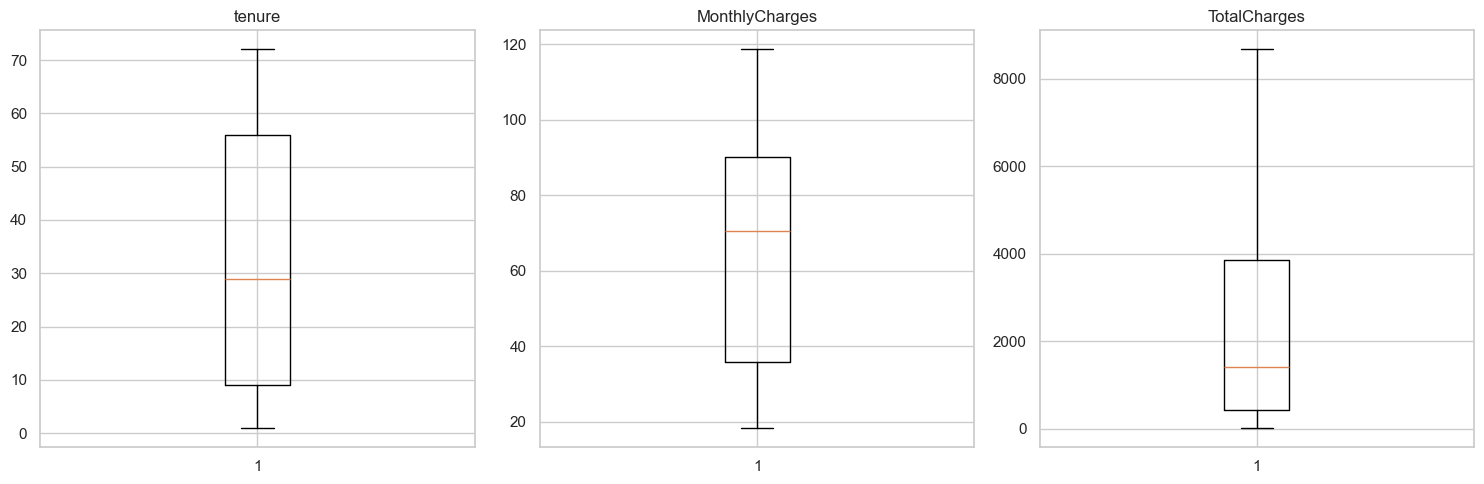

In [716]:
# Detectar valores atípicos (outliers) en las variables numéricas
# Utilizar un diagrama de caja (boxplot)
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, len(cols), figsize=(15, 5))
for ax, col in zip(axes, cols):
    ax.boxplot(data_train[col].dropna())
    ax.set_title(col)

plt.tight_layout()
plt.show()

- **No se detectaron valores atípicos (outliers)** en las columnas numéricas del conjunto de datos de prueba.

### Prueba de normalidad

In [717]:
# Variables a evaluar
variables = ['MonthlyCharges', 'tenure', 'TotalCharges']

# Nivel de significancia
alpha = 0.05

for var in variables:
    # Prueba K² de D'Agostino
    stat, p = stats.normaltest(data_train[var].dropna())

    print(f"\nVariable: {var}")
    print(f"Statistics = {stat:.5f}, p-value = {p:.5f}")

    if p > alpha:
        print("✓ La muestra sigue una distribución normal.")
    else:
        print("✗ La muestra no sigue una distribución normal.")


Variable: MonthlyCharges
Statistics = 7510.47646, p-value = 0.00000
✗ La muestra no sigue una distribución normal.

Variable: tenure
Statistics = 53555.33858, p-value = 0.00000
✗ La muestra no sigue una distribución normal.

Variable: TotalCharges
Statistics = 569.05463, p-value = 0.00000
✗ La muestra no sigue una distribución normal.


In [718]:
# Visualizar los tipos de datos
print("**Tipos de datos**")
data_train.dtypes.value_counts()

**Tipos de datos**


object     18
float64     2
int64       1
Name: count, dtype: int64

In [719]:
# Restablecer el índice y guardar el conjunto de datos en un archivo CSV
data_train.reset_index(drop=True, inplace=True)
data_train.to_csv(r"data\processed\data_train.csv", index=False)

## 2.2. Datos de prueba (Test Data)

### 2.2.1 Cargar y limpieza la base "LP2_Telco-churn-second-2000.csv"

In [720]:
data_test = pd.read_csv(r"data\raw\LP2_Telco-churn-second-2000.csv") 
data_test.info()
data_test.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        2000 non-null   object 
 1   gender            2000 non-null   object 
 2   SeniorCitizen     2000 non-null   int64  
 3   Partner           2000 non-null   object 
 4   Dependents        2000 non-null   object 
 5   tenure            2000 non-null   int64  
 6   PhoneService      2000 non-null   object 
 7   MultipleLines     2000 non-null   object 
 8   InternetService   2000 non-null   object 
 9   OnlineSecurity    2000 non-null   object 
 10  OnlineBackup      2000 non-null   object 
 11  DeviceProtection  2000 non-null   object 
 12  TechSupport       2000 non-null   object 
 13  StreamingTV       2000 non-null   object 
 14  StreamingMovies   2000 non-null   object 
 15  Contract          2000 non-null   object 
 16  PaperlessBilling  2000 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7613-LLQFO,Male,0,No,No,12,Yes,Yes,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,84.45,1059.55
1,4568-TTZRT,Male,0,No,No,9,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.40,181.8
2,9513-DXHDA,Male,0,No,No,27,Yes,No,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,No,Electronic check,81.70,2212.55
3,2640-PMGFL,Male,0,No,Yes,27,Yes,Yes,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,79.50,2180.55
4,3801-HMYNL,Male,0,Yes,Yes,1,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,No,Mailed check,89.15,89.15


In [721]:
# Cambiar el tipo de dato de la columna TotalCharges de objeto (object) a numérico
data_test['TotalCharges'] = pd.to_numeric(data_test['TotalCharges'], errors='coerce')

In [722]:
# Visualizar los valores faltantes en la columna TotalCharges
data_test[np.isnan(data_test['TotalCharges'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN
826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
1380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN


In [723]:
# Eliminar las filas donde tenure = 0
data_test.drop(labels=data_test[data_test['tenure'] == 0].index, axis=0, inplace=True)

In [724]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1997 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1997 non-null   object 
 1   gender            1997 non-null   object 
 2   SeniorCitizen     1997 non-null   int64  
 3   Partner           1997 non-null   object 
 4   Dependents        1997 non-null   object 
 5   tenure            1997 non-null   int64  
 6   PhoneService      1997 non-null   object 
 7   MultipleLines     1997 non-null   object 
 8   InternetService   1997 non-null   object 
 9   OnlineSecurity    1997 non-null   object 
 10  OnlineBackup      1997 non-null   object 
 11  DeviceProtection  1997 non-null   object 
 12  TechSupport       1997 non-null   object 
 13  StreamingTV       1997 non-null   object 
 14  StreamingMovies   1997 non-null   object 
 15  Contract          1997 non-null   object 
 16  PaperlessBilling  1997 non-null   object 
 17  

In [725]:
# Restablecer el índice
data_test.reset_index(drop=True, inplace=True)

In [726]:
# Verificar la existencia de valores nulos
data_test.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [727]:
# Verificar el tipo de dato de la columna SeniorCitizen
data_test['SeniorCitizen'].dtypes

dtype('int64')

In [728]:
# Reemplazar los valores 0 por 'No' y 1 por 'Sí'
data_test['SeniorCitizen'] = data_test['SeniorCitizen'].replace({0: 'No', 1: 'Si'})

In [729]:
# Reemplazar los valores True y False por Si y No en las columnas de tipo objeto
replace_values = {'Yes': 'Si', 'No': 'No'}

# Columnas binarias
binary_columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling']

# Utilizar el método replace()
for col in binary_columns:
    data_test[col] = data_test[col].replace(replace_values)

In [730]:
# Cambiar el tipo de dato a objeto (object)
data_test['SeniorCitizen'] = data_test['SeniorCitizen'].astype('object')

In [731]:
# Visualizar los valores únicos de cada columna
for column in data_test.columns:
    print('Column: {} - Unique Values: {}'.format(column, data_test[column].unique()))

Column: customerID - Unique Values: ['7613-LLQFO' '4568-TTZRT' '9513-DXHDA' ... '4816-JBHOV' '8920-NAVAY'
 '1699-TLDLZ']
Column: gender - Unique Values: ['Male' 'Female']
Column: SeniorCitizen - Unique Values: ['No' 'Si']
Column: Partner - Unique Values: ['No' 'Si']
Column: Dependents - Unique Values: ['No' 'Si']
Column: tenure - Unique Values: [12  9 27  1 24 14 32 11 38 54 29 44 59  3 18 67 22 33  5  2 72 16  8 23
 50 17 68 25 71 46 48 61 37 65 49 64 21 10  6 51 47 52 35 45  4 60 28 39
 30 55 58 26 43 56 36 13 70 69 41 15 19 31 34 66 40  7 53 63 42 57 62 20]
Column: PhoneService - Unique Values: ['Si' 'No']
Column: MultipleLines - Unique Values: ['Si' 'No' 'No phone service']
Column: InternetService - Unique Values: ['Fiber optic' 'No' 'DSL']
Column: OnlineSecurity - Unique Values: ['No' 'No internet service' 'Si']
Column: OnlineBackup - Unique Values: ['No' 'No internet service' 'Si']
Column: DeviceProtection - Unique Values: ['No' 'No internet service' 'Si']
Column: TechSupport - U

In [732]:
# Guardar los datos de prueba en un archivo CSV
data_test.to_csv(r"data\processed\data_test.csv", index=False)

# 3. Análisis exploratorio de datos

## 3.1. Prueba de hipótesis

**Hipótesis nula (H₀):**
"No existe una relación significativa entre la antigüedad del cliente (tenure) y la tasa de abandono (churn) en la empresa de telecomunicaciones."

**Hipótesis alternativa (Hₐ):**
"Existe una relación significativa entre la antigüedad del cliente (tenure) y la tasa de abandono (churn) en la empresa de telecomunicaciones."

Queremos determinar la correlación entre la antigüedad del cliente (**tenure**) y la tasa de abandono (**churn**). Dado que la tasa de abandono es una variable binaria, utilizaremos el **coeficiente de correlación punto-biserial (point-biserial)** para evaluar la significancia de la relación entre ambas variables.

In [733]:
# La variable 'Churn' debe ser una variable binaria (0 para no abandono y 1 para abandono)
data_hypo = data_train.copy()
data_hypo['Churn'] = data_hypo['Churn'].replace({'No': 0, 'Si': 1})

# Calcular el coeficiente de correlación punto-biserial
correlation_coefficient, p_value = stats.pointbiserialr(data_hypo['Churn'], data_hypo['tenure'])

# Imprimir los resultados
print(f"Point-Biserial Correlation Coefficient: {correlation_coefficient:.4f}")
print(f"P-value: {p_value:.4f}")

# Establecer el nivel de significancia (5 %)
alpha = 0.05

# Determinar si la correlación es estadísticamente significativa
if p_value < alpha:
    print("Existe una correlación significativa entre la antigüedad de los clientes y la tasa de abandono.")
else:
    print("No existe una correlación significativa entre la antigüedad de los clientes y la tasa de abandono.")

Point-Biserial Correlation Coefficient: -0.3526
P-value: 0.0000
Existe una correlación significativa entre la antigüedad de los clientes y la tasa de abandono.


- El **coeficiente de correlación de -0.3526** indica una **correlación negativa moderada**. Esto significa que, a medida que aumenta la antigüedad del cliente (**tenure**), la tasa de abandono (**Churn**) tiende a disminuir. En otras palabras, los clientes que han permanecido más tiempo en la empresa tienen una menor probabilidad de abandonar el servicio.

- El **valor p (p-value) de 0.0000** proporciona una fuerte evidencia estadística para **rechazar la hipótesis nula** (ausencia de correlación) a favor de la **hipótesis alternativa** (existencia de una correlación significativa). Por lo tanto, se concluye que existe una relación estadísticamente significativa entre la antigüedad del cliente (**tenure**) y la tasa de abandono (**Churn**).

## 3.2. Análisis Exploratorio de Datos (EDA)


### 3.2.1 Análisis Univariado

#### Distribución de la Tasa de Abandono de Clientes (Churn)

In [734]:
data_churn = data_train['Churn'].value_counts()
data_churn

Churn
No    3698
Si    1336
Name: count, dtype: int64

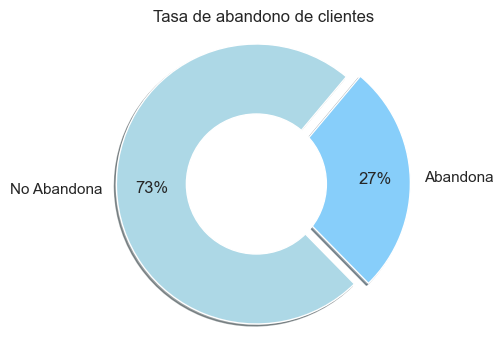

In [735]:
# Crear un gráfico circular (pie chart) con pyplot para visualizar la distribución de la variable Churn
plt.figure(figsize=(4, 4))

plt.pie(data_churn, labels=['No Abandona','Abandona'], colors=['LightBlue','LightSkyBlue'], startangle=50, shadow=True, radius=2,
     explode=(0,0.2),autopct='%1.0f%%', pctdistance=0.75 ,  )
Circle=plt.Circle((0,0), 1, color='white')
c= plt.gcf()

c.gca().add_artist(Circle)
# Una relación de aspecto igual garantiza que el gráfico circular se muestre como un círculo.
plt.axis('equal')  
plt.title('Tasa de abandono de clientes')

plt.show()

- La variable objetivo presenta un **desbalance de clases**.

- El porcentaje de clientes que **no abandonaron el servicio (clase mayoritaria)** puede utilizarse como una **línea base (baseline)** para evaluar el desempeño de los modelos desarrollados. Para que estos modelos sean considerados adecuados para realizar predicciones futuras, deben superar el rendimiento de esta línea base.

### 3.2.2 Análisis Bivariado y Multivariado

Analicemos la relación entre la abandono de clientes (Churn) y el género.

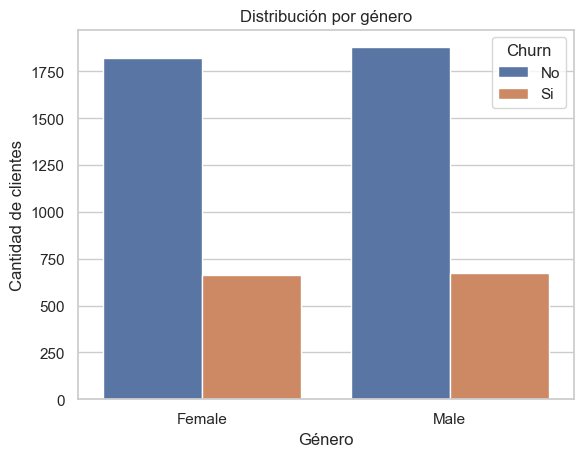

In [736]:
sns.countplot(x='gender',data=data_train,hue='Churn')
plt.title('Distribución por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de clientes')
plt.show()

- La distribución de clientes por género es prácticamente equilibrada entre hombres y mujeres, sin evidenciar una relación significativa entre el género y la probabilidad de abandono (churn).

##### **1. ¿Cuál es la relación entre la antigüedad del cliente (tenure) y la tasa de abandono? ¿Los clientes con mayor tiempo de permanencia tienen una mayor probabilidad de continuar con la empresa, mientras que los clientes más recientes presentan un mayor riesgo de abandono?**

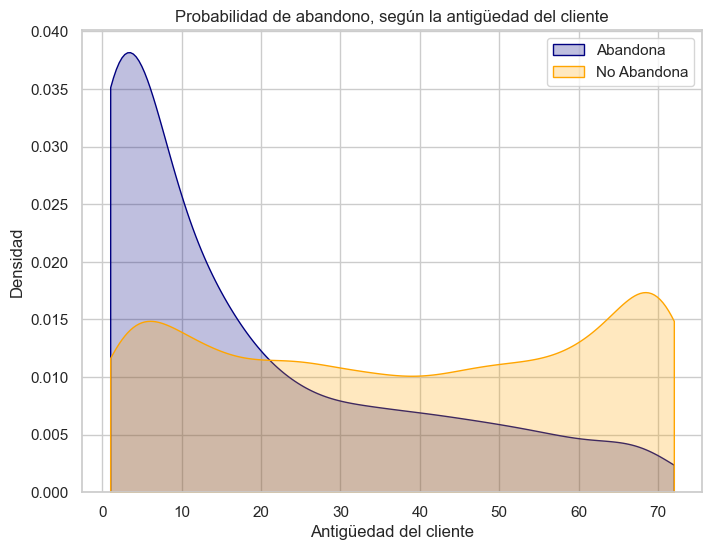

In [737]:
# Se utiliza una distribución de densidad de probabilidad para analizar cómo se distribuye el abandono (churn) según la antigüedad de los clientes.
def kdeplot(x):
    plt.figure(figsize=(8,6))
    plt.title('Probabilidad de abandono, según la antigüedad del cliente')
    plt.xlabel('Antigüedad del cliente')
    plt.ylabel('Densidad')    
    ax0= sns.kdeplot(data_train[data_train['Churn'] == 'Si'][x], color='navy', label='Churn:Si', fill =True, cut=0)
    ax1= sns.kdeplot(data_train[data_train['Churn'] == 'No'][x], color='orange', label='Churn:No', fill=True, cut=0)
    plt.legend(['Abandona', 'No Abandona'], loc='upper right')

kdeplot('tenure')


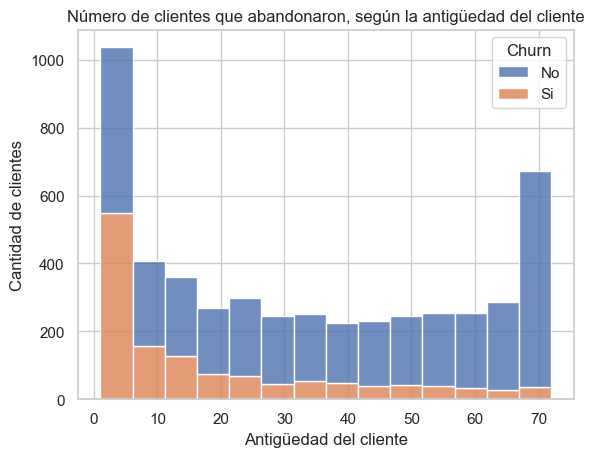

In [738]:
sns.histplot(x='tenure', hue='Churn', data=data_train, bins=14, alpha=0.8, multiple='stack')
plt.title('Número de clientes que abandonaron, según la antigüedad del cliente')
plt.xlabel('Antigüedad del cliente')
plt.ylabel('Cantidad de clientes')
plt.show()

- Los clientes con menor antigüedad (clientes recientes) tienen una mayor probabilidad de abandonar la empresa (churn).
- Los clientes con mayor antigüedad presentan una menor probabilidad de abandono.

##### **2. ¿Existe una correlación entre el cargo total (TotalCharges) y la tasa de abandono? ¿Los clientes con mayores cargos totales presentan un comportamiento de abandono diferente en comparación con aquellos con menores cargos?**

Correlation coefficient: -0.19462794572065176
P-value: 3.667843370778272e-44


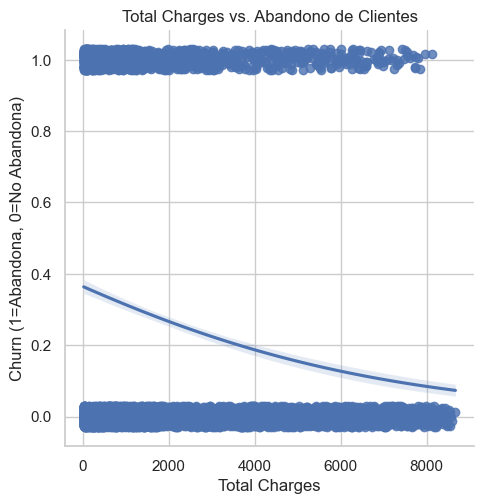

In [739]:
data_temp = data_hypo

# Convertir la columna "TotalCharges" a un tipo de dato numérico y posteriormente a valores enteros.
data_temp["TotalCharges"] = pd.to_numeric(data_temp["TotalCharges"], errors="coerce", downcast="integer")

# Calcular la correlación biserial puntual (point-biserial) entre TotalCharges y Churn.
corr, p_value = pointbiserialr(data_temp["TotalCharges"], data_temp["Churn"])

# Mostrar el coeficiente de correlación y el valor p (p-value).
print("Correlation coefficient:", corr)
print("P-value:", p_value)

# Graficar los datos para visualizar la relación entre TotalCharges y Churn.
# Aplicar una regresión logística para modelar la variable dependiente binaria (Churn).
sns.lmplot(data=data_temp, x="TotalCharges", y="Churn", logistic=True, y_jitter=.03)
plt.title("Total Charges vs. Abandono de Clientes")
plt.xlabel("Total Charges")
plt.ylabel("Churn (1=Abandona, 0=No Abandona)")
plt.show()

El análisis muestra una **correlación negativa débil** entre los cargos totales (TotalCharges) y la tasa de abandono (churn). A medida que aumentan los cargos totales, la probabilidad de abandono disminuye ligeramente. La relación es **estadísticamente significativa** (valor p < 0.05); sin embargo, el tamaño del efecto es reducido. Esto sugiere que otros factores podrían tener una mayor influencia en el comportamiento de abandono de los clientes.

##### **3. ¿Cuál es el impacto del tipo de contrato en la tasa de abandono? ¿Los clientes con contratos de largo plazo presentan tasas de abandono significativamente menores que aquellos con contratos de corto plazo?**

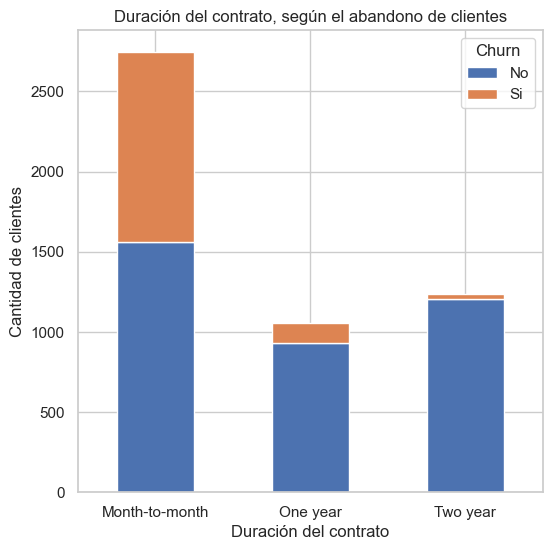

In [740]:
# Crear una tabla de contingencia (crosstab) entre la variable categórica y la columna 'Churn'.
cross_tab = pd.crosstab(data_train['Contract'], data_train['Churn'])

# Graficar un diagrama de barras apiladas (stacked bar chart) utilizando Seaborn.
ax = cross_tab.plot(kind="bar", stacked=True, figsize=(6, 6))
plt.title("Duración del contrato, según el abandono de clientes")
plt.xlabel("Duración del contrato")
plt.xticks(rotation=0)
plt.ylabel("Cantidad de clientes")
plt.legend(title="Churn", loc="upper right")
plt.show()

- Los clientes con contratos de corto plazo (mes a mes) presentan tasas de abandono significativamente más altas que aquellos con contratos de largo plazo (uno o más años).
- Algunas posibles razones incluyen la sensibilidad al precio, una mayor competencia, procesos de incorporación (onboarding) poco efectivos y cambios en las necesidades de los clientes. Para reducir el abandono en contratos de corto plazo, es recomendable ofrecer experiencias personalizadas, precios competitivos y mejorar el proceso de incorporación. Además, fortalecer la relación con los clientes y demostrar el valor de largo plazo del servicio puede fomentar una mayor fidelización.

##### **4. ¿Existen diferencias significativas en el comportamiento de abandono entre los clientes que cuentan con protección para el dispositivo y aquellos que no?**

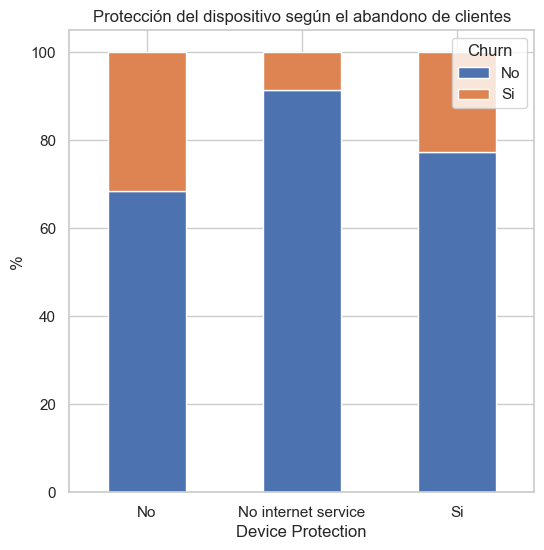

In [741]:
# Crear una tabla de contingencia (crosstab) entre la variable categórica y la columna 'Churn'
cross_tab = pd.crosstab(data_train['DeviceProtection'], data_train['Churn'])

# Graficar un gráfico de barras apiladas utilizando Seaborn
percentages = cross_tab.div(cross_tab.sum(1), axis=0) * 100

# Graficar un gráfico de barras apiladas utilizando Seaborn
ax = percentages.plot(kind="bar", stacked=True, figsize=(6, 6))
plt.title("Protección del dispositivo según el abandono de clientes")
plt.xlabel("Device Protection")
plt.xticks(rotation=0)
plt.ylabel("%")
plt.legend(title="Churn", loc="upper right")

plt.show()

- Los clientes que no cuentan con protección para el dispositivo presentan una probabilidad ligeramente mayor de abandonar la empresa, aunque la diferencia no es lo suficientemente significativa.

##### **5. ¿Cuál es la relación entre la disponibilidad de soporte técnico y la tasa de abandono? ¿Los clientes que tienen acceso a soporte técnico tienen una mayor probabilidad de permanecer en la empresa?**

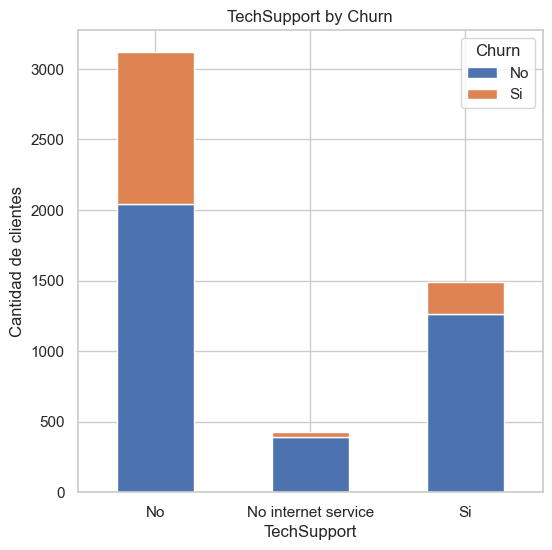

In [742]:
# Create a cross-tabulation (crosstab) of the categorical column and 'Churn' column
cross_tab = pd.crosstab(data_train['TechSupport'], data_train['Churn'])

# Plot the stacked bar plot using Seaborn
# sns.set(style="whitegrid")
ax = cross_tab.plot(kind="bar", stacked=True, figsize=(6, 6))
plt.title("TechSupport by Churn")
plt.xlabel("TechSupport")
plt.xticks(rotation=0)
plt.ylabel("Cantidad de clientes")
plt.legend(title="Churn", loc="upper right")

plt.show()

- Los clientes que no cuentan con soporte técnico presentaron una mayor probabilidad de abandonar la empresa.

##### **6. ¿Los servicios de streaming influyen en el abandono de clientes? ¿Los clientes que cuentan con servicios como StreamingTV y StreamingMovies tienen más probabilidades de permanecer en la empresa?**


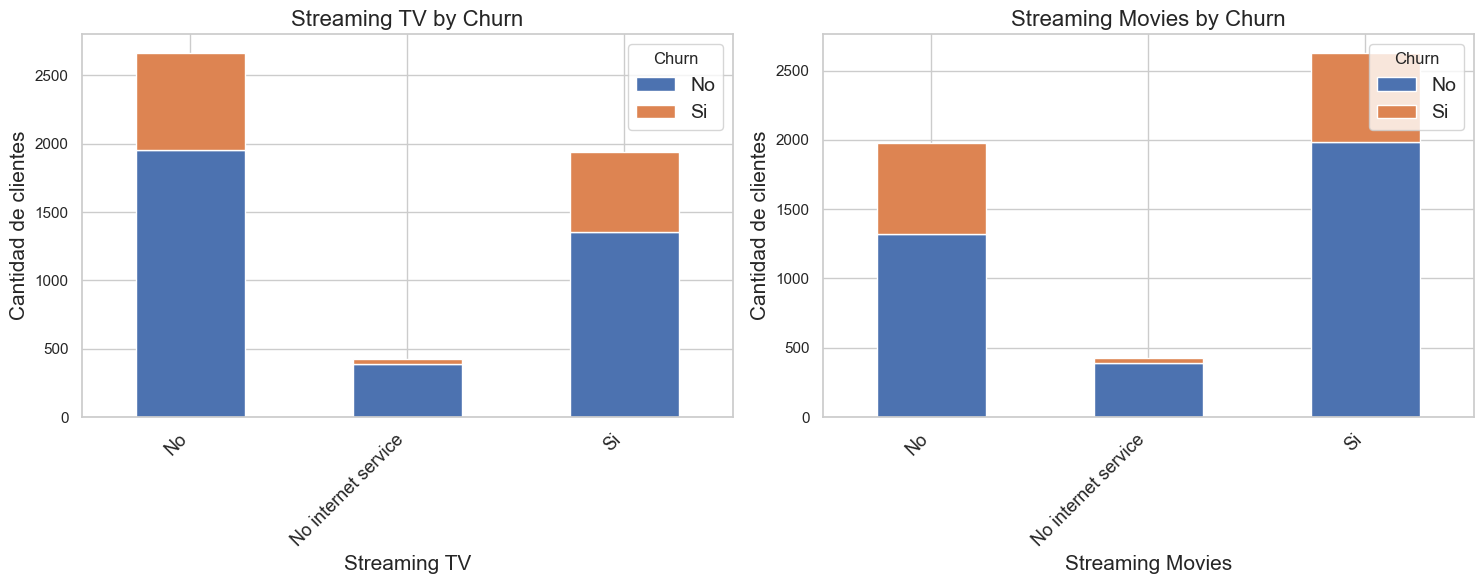

In [743]:
# Crear una tabla de contingencia (crosstab) entre las dos variables categóricas y la columna 'Churn'
cross_tab1 = pd.crosstab(data_train['StreamingTV'], data_train['Churn'])
cross_tab2 = pd.crosstab(data_train['StreamingMovies'], data_train['Churn'])

# Configurar los subgráficos (subplots)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Graficar el primer gráfico de barras apiladas
cross_tab1.plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Streaming TV by Churn", fontsize=16)
axes[0].set_xlabel("Streaming TV", fontsize=15)
axes[0].set_ylabel("Cantidad de clientes", fontsize=15)
axes[0].legend(title="Churn", loc="upper right", fontsize=14)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=13)

# Graficar el segundo gráfico de barras apiladas
cross_tab2.plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Streaming Movies by Churn", fontsize=16)
axes[1].set_xlabel("Streaming Movies",fontsize=15)
axes[1].set_ylabel("Cantidad de clientes", fontsize=15)
axes[1].legend(title="Churn", loc="upper right", fontsize=14)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=13)

# Ajustar el diseño y mostrar los gráficos
plt.tight_layout()
plt.show()

- No se observó una relación significativa entre los servicios de streaming y las tasas de abandono de clientes.

##### **7. ¿Cómo influye el método de pago en las tasas de abandono? ¿Los clientes que utilizan determinados métodos de pago tienen una mayor propensión a abandonar la empresa?**

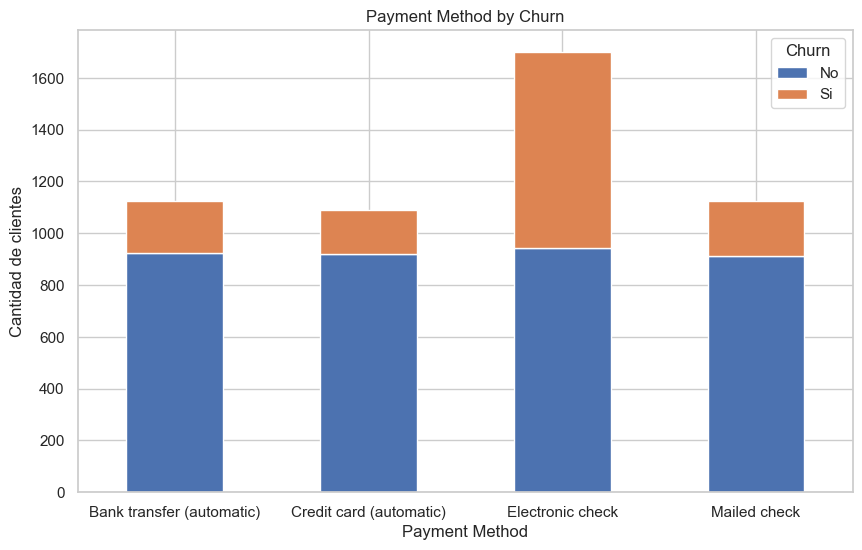

In [744]:
# Crear una tabla de contingencia (crosstab) entre la variable categórica y la columna 'Churn'
cross_tab = pd.crosstab(data_train['PaymentMethod'], data_train['Churn'])

# Graficar un gráfico de barras apiladas utilizando Seaborn
sns.set(style="whitegrid")
ax = cross_tab.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Payment Method by Churn")
plt.xlabel("Payment Method")
plt.xticks(rotation=0)
plt.ylabel("Cantidad de clientes")
plt.legend(title="Churn", loc="upper right")

plt.show()

- Los clientes que realizan sus pagos mediante cheque electrónico (Electronic Check) mostraron una mayor probabilidad de abandonar la empresa.

### 3.2.3. Análisis Multivariado

Analicemos la correlación entre las variables numéricas y la variable objetivo (Churn).

In [745]:
numeric_columns = data_hypo.select_dtypes(include=['int64', 'float64'])
numeric_columns.corr()

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.239642,0.826188,-0.352634
MonthlyCharges,0.239642,1.000000,0.646813,0.201995
TotalCharges,0.826188,0.646813,1.000000,-0.194628
Churn,-0.352634,0.201995,-0.194628,1.000000


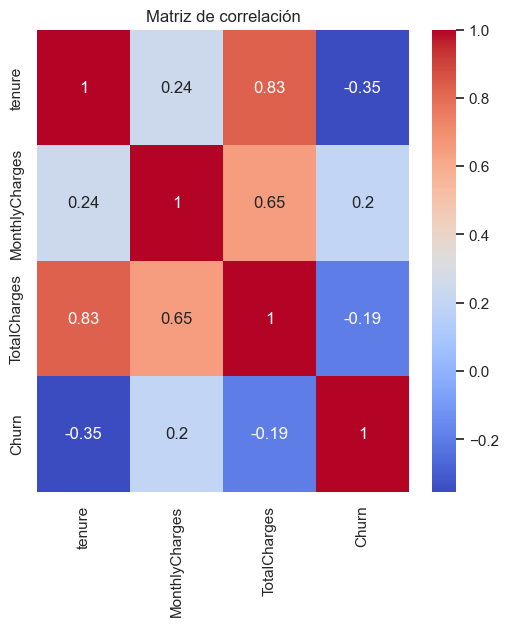

In [746]:
plt.figure(figsize=(6,6))
sns.heatmap(numeric_columns.corr(),annot=True,cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

1. **Tenure vs. Churn**: El coeficiente de correlación negativo (-0.352634) indica una relación lineal negativa moderada entre ambas variables. A medida que aumenta la antigüedad del cliente (tenure), la probabilidad de abandono (Churn) tiende a disminuir.

2. **MonthlyCharges vs. Churn**: El coeficiente de correlación positivo (0.201995) indica una relación lineal positiva débil. A medida que aumentan los cargos mensuales (MonthlyCharges), la probabilidad de abandono también tiende a incrementarse ligeramente. Sin embargo, esta relación es considerablemente más débil que la observada con tenure.

3. **TotalCharges vs. Churn**: El coeficiente de correlación negativo (-0.194628) sugiere una relación lineal negativa débil. A medida que aumentan los cargos totales acumulados (TotalCharges), la probabilidad de abandono tiende a disminuir ligeramente. Al igual que ocurre con MonthlyCharges, esta relación es menos fuerte que la existente entre tenure y 'Churn'.

## 3.3. Procesamiento e Ingeniería de Características

En esta sección se **limpiará**, **procesará el conjunto de datos** y se **crearán nuevas características (features)**.

In [747]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5034 non-null   object 
 1   gender            5034 non-null   object 
 2   SeniorCitizen     5034 non-null   object 
 3   Partner           5034 non-null   object 
 4   Dependents        5034 non-null   object 
 5   tenure            5034 non-null   int64  
 6   PhoneService      5034 non-null   object 
 7   MultipleLines     5034 non-null   object 
 8   InternetService   5034 non-null   object 
 9   OnlineSecurity    5034 non-null   object 
 10  OnlineBackup      5034 non-null   object 
 11  DeviceProtection  5034 non-null   object 
 12  TechSupport       5034 non-null   object 
 13  StreamingTV       5034 non-null   object 
 14  StreamingMovies   5034 non-null   object 
 15  Contract          5034 non-null   object 
 16  PaperlessBilling  5034 non-null   object 


In [748]:
# Eliminar la columna CustomerID
del data_train["customerID"]

### Puntajes de Información Mutua (Mutual Information, MI)

Calculamos los puntajes de Información Mutua (MI) entre las variables categóricas y la variable objetivo (Churn) en el conjunto de datos de prueba. La Información Mutua es una medida de dependencia entre dos variables que cuantifica cuánto reduce la incertidumbre sobre una variable el conocimiento de la otra.

Este análisis permite identificar qué variables categóricas son más informativas con respecto a la variable objetivo, por lo que pueden resultar especialmente útiles para predecir o comprender el comportamiento del abandono de clientes (Churn).

In [749]:
# Evaluemos la dependencia de las variables con la variable objetivo utilizando el puntaje de Información Mutua (Mutual Information, MI).
x_cat = data_train.select_dtypes(include=object).drop('Churn', axis=1)
y_cat = data_train['Churn']

mi_scores = []

# Recorrer cada variable categórica para calcular el puntaje de Información Mutua (MI)
# con respecto a la variable objetivo ('Churn').
for column in x_cat.columns:
    mi_score = mutual_info_score(x_cat[column], y_cat)
    mi_scores.append((column, mi_score))

# Ordenar las variables según su nivel de dependencia con la variable objetivo,
# ubicando las más importantes al inicio.
mi_scores.sort(key=lambda x: x[1], reverse=True)

for feature, score in mi_scores:
    print(f"{feature} - {score}")

Contract - 0.10284790516675524
InternetService - 0.05944428811167132
PaymentMethod - 0.04163984913943765
TechSupport - 0.030007109249305178
OnlineSecurity - 0.029670157336360276
PaperlessBilling - 0.019508874345666505
OnlineBackup - 0.015826778687180174
Dependents - 0.015615368107435551
DeviceProtection - 0.013717699147021103
StreamingMovies - 0.013349078621584257
SeniorCitizen - 0.010389723457655958
Partner - 0.010018147440621322
StreamingTV - 0.009953736504141789
MultipleLines - 0.0008281912846177519
PhoneService - 0.00010045042468448395
gender - 3.2190163546386152e-06


In [750]:
import plotly.io as pio

print(pio.renderers.default)
print(pio.renderers)

vscode
Renderers configuration
-----------------------
    Default renderer: 'vscode'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']



In [751]:
features = [score[0] for score in mi_scores]
scores = [score[1] for score in mi_scores]

# Crear un gráfico de barras utilizando Plotly
fig = px.bar(x=scores, y=features, orientation='h', color=scores,
             labels={'x': 'Mutual Information Score', 'y': 'Variables'},
             title='Relación entre las variables categóricas y la variable objetivo (Churn)',
             template='plotly_dark',
             color_continuous_scale=px.colors.sequential.Plasma)
fig.show()

- Las variables género (Gender), servicio telefónico (PhoneService) y múltiples líneas (MultipleLines) presentan un puntaje de Información Mutua (MI) muy bajo (cercano a 0). Esto sugiere que tienen poca o ninguna capacidad predictiva o relación con la variable objetivo.
- Las variables tipo de contrato (Contract) y servicio de internet (InternetService) presentan los puntajes de Información Mutua más altos. Esto indica que la duración del contrato y el tipo de servicio de internet de un cliente pueden estar asociados con diferentes tasas de abandono.


In [752]:
images_path = 'images\Mutual_information_plot.png'

# Guardar la figura como una imagen PNG
pio.write_image(fig, images_path)

In [753]:
# Eliminar columnas
data_train.drop(columns=['gender','PhoneService', 'MultipleLines'], inplace=True)

In [754]:
df_encode = data_train.copy()

### X-Y Split

In [755]:
X = df_encode.drop(columns=['Churn'])
y = df_encode['Churn']

### Codificación de etiquetas (Label Encoding)

In [756]:
# Codificar la variable objetivo (Churn) para que tome los valores 0 y 1 en lugar de No y Yes.
labelEncoder = LabelEncoder()
y = labelEncoder.fit_transform(y)

In [757]:
(X.shape, y.shape)

((5034, 16), (5034,))

### Codificación One-Hot

In [758]:
# Aplicar codificación One-Hot a las variables categóricas.
categorical_columns = ['SeniorCitizen', 'Partner', 'Dependents','InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

# Crear una instancia del transformador de columnas.
transformer = make_column_transformer(
    (OneHotEncoder(sparse_output=False), categorical_columns)
)
transformed_data = transformer.fit_transform(X[categorical_columns])

# Transformar los datos nuevamente a un DataFrame.
transformed_df = pd.DataFrame(transformed_data, columns=transformer.get_feature_names_out())

# La codificación One-Hot eliminó el índice. Volvamos a agregarlo.
transformed_df.index = X.index

# Unir las tablas.
encoded_df = pd.concat([X, transformed_df], axis=1)

# Eliminar las columnas categóricas originales.
encoded_df.drop(categorical_columns, axis=1, inplace=True)

In [759]:
encoded_df.head()

,tenure,MonthlyCharges,TotalCharges,onehotencoder__SeniorCitizen_No,onehotencoder__SeniorCitizen_Si,onehotencoder__Partner_No,onehotencoder__Partner_Si,onehotencoder__Dependents_No,onehotencoder__Dependents_Si,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__OnlineSecurity_No,onehotencoder__OnlineSecurity_No internet service,onehotencoder__OnlineSecurity_Si,onehotencoder__OnlineBackup_No,onehotencoder__OnlineBackup_No internet service,onehotencoder__OnlineBackup_Si,onehotencoder__DeviceProtection_No,onehotencoder__DeviceProtection_No internet service,onehotencoder__DeviceProtection_Si,onehotencoder__TechSupport_No,onehotencoder__TechSupport_No internet service,onehotencoder__TechSupport_Si,onehotencoder__StreamingTV_No,onehotencoder__StreamingTV_No internet service,onehotencoder__StreamingTV_Si,onehotencoder__StreamingMovies_No,onehotencoder__StreamingMovies_No internet service,onehotencoder__StreamingMovies_Si,onehotencoder__Contract_Month-to-month,onehotencoder__Contract_One year,onehotencoder__Contract_Two year,onehotencoder__PaperlessBilling_No,onehotencoder__PaperlessBilling_Si,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check
0,1,29.850000,29.850000,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,34,56.950001,1889.500000,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,2,53.849998,108.150002,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,45,42.299999,1840.750000,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,2,70.699997,151.649994,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [760]:
encoded_df.columns = encoded_df.columns.str.replace('onehotencoder__', '')

In [761]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   tenure                                   5034 non-null   int64  
 1   MonthlyCharges                           5034 non-null   float64
 2   TotalCharges                             5034 non-null   float64
 3   SeniorCitizen_No                         5034 non-null   float64
 4   SeniorCitizen_Si                         5034 non-null   float64
 5   Partner_No                               5034 non-null   float64
 6   Partner_Si                               5034 non-null   float64
 7   Dependents_No                            5034 non-null   float64
 8   Dependents_Si                            5034 non-null   float64
 9   InternetService_DSL                      5034 non-null   float64
 10  InternetService_Fiber optic              5034 no

### Escalado de variables (Feature Scaling)

In [762]:
# Aplicar estandarización a las variables numéricas.
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

encoded_scaled = scaler.fit_transform(encoded_df[cols])

# Crear nuevos DataFrames con los valores escalados.
X_scaled_df = pd.DataFrame(encoded_scaled, columns=cols, index=X.index)

# Eliminar las columnas originales sin escalar.
encoded_df.drop(cols, axis=1, inplace=True)

# Concatenar las columnas escaladas con los DataFrames originales.
encoded_df = pd.concat([encoded_df, X_scaled_df], axis=1)

In [763]:
encoded_df.head()

,SeniorCitizen_No,SeniorCitizen_Si,Partner_No,Partner_Si,Dependents_No,Dependents_Si,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Si,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Si,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Si,TechSupport_No,TechSupport_No internet service,TechSupport_Si,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Si,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Si,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Si,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure,MonthlyCharges,TotalCharges
0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-1.290184,-1.172700,-1.001315
1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.056283,-0.271320,-0.181408
2,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-1.249382,-0.374430,-0.966794
3,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.505106,-0.758597,-0.202901
4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-1.249382,0.186022,-0.947615


### Balanceo del conjunto de entrenamiento (Algoritmo SMOTE)

SMOTE (Synthetic Minority Over-sampling Technique) es una técnica utilizada para abordar el desbalance de clases en problemas de clasificación binaria.

Anteriormente identificamos que nuestra variable objetivo presenta un desbalance de clases: una de ellas (la clase minoritaria) tiene un número significativamente menor de observaciones que la otra (la clase mayoritaria). Este desbalance puede afectar negativamente el rendimiento de los modelos de machine learning, ya que estos tienden a favorecer la clase mayoritaria durante el proceso de aprendizaje.

SMOTE busca equilibrar la distribución de las clases mediante la generación de muestras sintéticas de la clase minoritaria hasta igualar el número de observaciones de la clase mayoritaria. Al crear estas nuevas muestras, SMOTE permite que el modelo capture mejor los patrones de la clase minoritaria, reduciendo el sesgo hacia la clase mayoritaria y mejorando su capacidad de generalización.

In [764]:
# Aplicar SMOTE al conjunto de entrenamiento (sobremuestreo).
smote = SMOTE(random_state=42, k_neighbors=5, sampling_strategy='auto')

X_resampled, y_resampled = smote.fit_resample(encoded_df, y)

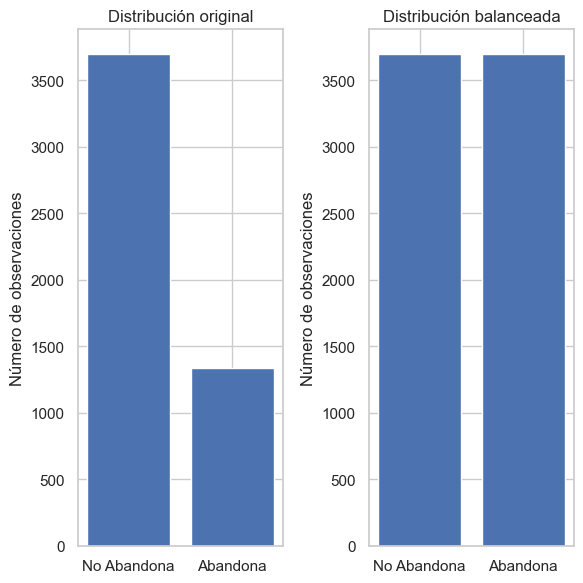

In [765]:
fig, axes = plt.subplots(1, 2, figsize=(6, 6))

# Graficar la distribución original de las clases.
unique, counts = np.unique(y, return_counts=True)
axes[0].bar(unique, counts)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Abandona', 'Abandona'])
axes[0].set_ylabel('Número de observaciones')
axes[0].set_title('Distribución original')

# Graficar la distribución de las clases después de aplicar SMOTE.
unique2, counts2 = np.unique(y_resampled, return_counts=True) 
axes[1].bar(unique2, counts2)
axes[1].set_xticks([0, 1])  # Ajustar el límite del eje Y según sea necesario.
axes[1].set_xticklabels(['No Abandona', 'Abandona'])  # Configurar las etiquetas de los ejes y los títulos.
axes[1].set_ylabel('Número de observaciones')
axes[1].set_title('Distribución balanceada')

# Ajustar el espaciado entre los subgráficos.
plt.tight_layout()

# Mostrar los subgráficos.
plt.show()

El conjunto de entrenamiento se encuentra ahora balanceado.

#### División del conjunto de datos en entrenamiento y prueba

In [766]:
# Dividir el conjunto de datos en entrenamiento y prueba.
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

In [767]:
# Verificar las dimensiones de los datos después del balanceo.
pd.DataFrame(X_train).shape, pd.DataFrame(y_train).shape

((5916, 39), (5916, 1))

In [768]:
# Visualizar la distribución de las clases.
pd.value_counts(pd.Series(y_train))

0    2958
1    2958
Name: count, dtype: int64

# 4. Modelado 
En esta sección se **construyen**, **entrenan**, **evalúan** y **comparan** los diferentes modelos de aprendizaje automático.

## 4.1. Modelo 1: Regresión logística (Logistic Regression)

In [769]:
LR = LogisticRegression(random_state=42)

# Entrenar el modelo
LR.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## 4.2. Modelo 2: K vecinos más cercanos (K-Nearest Neighbors, KNN)

In [770]:
knn = KNeighborsClassifier()

# Entrenar el modelo
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## 4.3. Modelo 3: Bosque aleatorio (Random Forest)

In [771]:
rfm = RandomForestClassifier(random_state=42)

# Entrenar el modelo
rfm.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 4.4. Modelo 4: Máquina de vectores de soporte (Support Vector Machine, SVM)

In [772]:
svm = SVC(random_state=42)

# Entrenar el modelo
svm.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## 4.5. Modelo 5: Gradient Boosting

In [773]:
gb = GradientBoostingClassifier(random_state=42)

# Entrenar el modelo
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## 4.6. Modelo 6: XGBoost

In [774]:
xgb = XGBClassifier(random_state=42)

# Entrenar el modelo
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


# 5. Evaluación de modelos
Creamos un DataFrame de pandas que nos permitirá comparar el rendimiento de los diferentes modelos.

## 5.1. Validación cruzada K-Fold

La validación cruzada K-Fold es una técnica que permite estimar el rendimiento de los modelos utilizando múltiples subconjuntos de los datos (k particiones), proporcionando una evaluación más completa de su capacidad de generalización. En este proceso, el modelo se entrena y evalúa k veces, utilizando en cada iteración una partición diferente como conjunto de validación, mientras que las restantes se emplean para el entrenamiento. Esto permite estimar el desempeño del modelo sobre distintos subconjuntos del conjunto de datos.

Esta técnica ayuda a evaluar qué tan bien se desempeñará el modelo sobre datos nuevos y no observados, además de proporcionar información sobre su estabilidad, consistencia y capacidad de generalización.

In [775]:
# Crear un DataFrame con los resultados de la validación cruzada K-Fold.
models = [
    ('Logistic Regression', LR),
    ('K nearest neighbors', knn),
    ('Random Forest', rfm),
    ('SVC', svm),
    ('Gradient Boosting', gb),
    ('XGBoost', xgb)
]

# Número de particiones (k-folds).
k = 5

results = []

for name, model in models:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)  # Crear un objeto KFold.
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')

    # Agregar los resultados a la lista.
    results.append((name, scores.mean(), scores.std()))

results_df = pd.DataFrame(results, columns=['Model', 'Mean Accuracy', 'Std Deviation'])

results_df.sort_values(by='Mean Accuracy', ascending=False)

,Model,Mean Accuracy,Std Deviation
2,Random Forest,0.851251,0.008510
5,XGBoost,0.841784,0.008328
4,Gradient Boosting,0.840263,0.015050
3,SVC,0.806117,0.009330
1,K nearest neighbors,0.787355,0.009394
0,Logistic Regression,0.775352,0.013425


La salida de nuestra **validación cruzada k-fold** presenta la **exactitud promedio (mean accuracy)** y la **desviación estándar (standard deviation)** obtenidas para cada modelo.

1. **Exactitud promedio (Average Accuracy)** corresponde al promedio de la exactitud obtenida en todos los *k* pliegues durante el proceso de validación cruzada. Valores más altos de exactitud promedio indican un mejor desempeño predictivo del modelo.

2. **Desviación estándar (Standard Deviation)** mide la variabilidad o dispersión de los valores de exactitud entre los diferentes *k* pliegues. Una desviación estándar baja sugiere que el rendimiento del modelo es consistente en los distintos subconjuntos de datos, mientras que una desviación estándar alta indica una mayor variación en su desempeño. En general, se prefieren desviaciones estándar más pequeñas, ya que reflejan un modelo más estable y confiable.

El modelo **Random Forest Classifier** obtuvo la mayor exactitud promedio (**0.846180**, aproximadamente **85 %**) entre todos los modelos evaluados. Esto significa que, en promedio, el modelo clasificó correctamente la variable objetivo en alrededor del **85 %** de las observaciones en cada uno de los pliegues de la validación cruzada.

## 5.2. Classification Report

In [776]:
model_names = ['Logistic Regression', 'k-NN', 'Random Forest', 'SVM', 'Gradient Boosting', 'XGBoost']
models = [LR, knn, rfm, svm, gb, xgb]
model_names_list = []
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Iterar sobre cada modelo para calcular las métricas y almacenar la información
for name, model in zip(model_names, models):
    # Realizar predicciones sobre el conjunto de prueba
    y_pred = model.predict(X_test)
    
    # Calcular las métricas: exactitud (accuracy), precisión (precision), sensibilidad (recall) y puntuación F1 (F1-score)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Almacenar el nombre del modelo y las métricas obtenidas
    model_names_list.append(name)
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

# Crear un DataFrame con las métricas calculadas
metrics_df = pd.DataFrame({
    'Model': model_names_list,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores
})

# Mostrar el DataFrame
metrics_df.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.856081,0.849007,0.866216,0.857525
5,XGBoost,0.850676,0.844622,0.859459,0.851976
4,Gradient Boosting,0.842568,0.824584,0.870270,0.846811
3,SVM,0.798649,0.779040,0.833784,0.805483
1,k-NN,0.791216,0.734494,0.912162,0.813743
0,Logistic Regression,0.778378,0.754950,0.824324,0.788114


- El modelo **XGBoost** obtuvo el mejor desempeño, alcanzando una **exactitud (accuracy)** de **0.852027**, equivalente a aproximadamente **85 %**.

- Los tres modelos con mejor rendimiento (**Random Forest**, **XGBoost** y **Gradient Boosting**) pertenecen a la familia de modelos basados en árboles, específicamente a técnicas de **aprendizaje por conjuntos (*ensemble learning*)**. Estos métodos combinan múltiples árboles de decisión para mejorar el rendimiento predictivo y la robustez del modelo. Además, reducen el sobreajuste (*overfitting*) mediante estrategias como el promedio de las predicciones o el proceso de potenciación (*boosting*). Gracias a estas características, ofrecen una combinación de alta precisión, estabilidad y versatilidad, lo que los convierte en excelentes alternativas para tareas de clasificación en una amplia variedad de dominios y tipos de datos.


In [777]:
# Ordenar el DataFrame por la columna 'Accuracy' en orden ascendente
metrics_df_sorted = metrics_df.sort_values(by='Accuracy')

# Crear el gráfico
fig = px.bar(metrics_df_sorted, x='Model', y='Accuracy', color='Model',
             title='Model Performance Metrics (Accuracy)',
             template='plotly_dark',
             labels={'Model': 'Nombre del modelo', 'Accuracy': 'Accuracy Score'}
            )

# Mostrar el gráfico
fig.show()

Estas son las métricas de desempeño obtenidas a partir de nuestro **reporte de clasificación**, las cuales nos permiten evaluar el rendimiento de los diferentes modelos.

1. **Exactitud (Accuracy):** La exactitud mide la proporción de predicciones correctas respecto al total de observaciones del conjunto de datos. Es una de las métricas más utilizadas en problemas de clasificación. En nuestro caso, el modelo **XGBoost** obtuvo la mayor exactitud (**0.852**), lo que significa que aproximadamente el **85 %** de las observaciones fueron clasificadas correctamente.

   Dado que nuestro conjunto de datos se encuentra **balanceado**, la exactitud es una métrica adecuada para evaluar el desempeño general del modelo. En este contexto, existe un menor riesgo de que el modelo favorezca una clase sobre la otra debido al desbalance de clases. Por ello, una alta exactitud indica que el modelo clasifica correctamente ambas clases y presenta un buen rendimiento global.

2. **Precisión (Precision):** La precisión mide la proporción de predicciones positivas realizadas por el modelo que realmente corresponden a casos positivos. Se calcula como la razón entre los **verdaderos positivos (True Positives)** y el total de observaciones clasificadas como positivas (**verdaderos positivos + falsos positivos**). Un mayor valor de precisión implica una menor cantidad de falsos positivos.

   En el modelo **XGBoost**, la precisión es aproximadamente **0.8487**, lo que significa que cerca del **85 %** de las observaciones clasificadas como positivas fueron correctamente identificadas.

3. **Sensibilidad (Recall):** La sensibilidad, también conocida como **tasa de verdaderos positivos** (*True Positive Rate*), mide la proporción de casos positivos reales que fueron correctamente identificados por el modelo. Se calcula como la razón entre los **verdaderos positivos** y el total de casos positivos reales (**verdaderos positivos + falsos negativos**). Un valor alto de *recall* indica una menor cantidad de falsos negativos.

   En el modelo **XGBoost**, la sensibilidad es aproximadamente **0.8568**, lo que indica que alrededor del **86 %** de los casos positivos reales fueron detectados correctamente.

4. **Puntuación F1 (F1-Score):** La puntuación F1 es la **media armónica** entre la precisión y la sensibilidad (*recall*). Esta métrica combina ambas medidas en un único indicador, proporcionando una evaluación equilibrada del modelo al considerar simultáneamente los falsos positivos y los falsos negativos.

En el modelo **XGBoost**, el **F1-Score** es aproximadamente **0.8527**, lo que refleja un buen equilibrio entre la precisión y la capacidad del modelo para identificar correctamente los casos positivos.


In [778]:
images_path = r"images\Model_Performance_Accuracy.png"

# Guardar la figura como una imagen PNG
pio.write_image(fig, images_path)

## 5.3. Ajuste de Hiperparámetros

Realizaremos el **ajuste de hiperparámetros** (*Hyperparameter Tuning*) de nuestros **tres mejores modelos** utilizando `RandomizedSearchCV` (disponible en `sklearn.model_selection`). El objetivo es encontrar la combinación óptima de hiperparámetros para maximizar el rendimiento de cada modelo y, posteriormente, compararlos nuevamente para seleccionar el mejor.

### 5.3.1. Ajuste del Modelo 1 (XGBoost)

In [779]:
# Verificar los parámetros actuales del modelo
current_params = xgb.get_params()
current_params

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': True,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [780]:
# Ajuste de hiperparámetros del modelo XGBoost
param_dist = {
    'n_estimators': [None, 50, 100, 500, 1000],
    'max_depth': [None, 3, 5, 7, 10],
    'min_child_weight': [None, 1, 2, 4, 6],
    'subsample': [None, 0.1, 0.2, 0.4, 0.6],
    'gamma': [None, 0, 0.1, 0.2, 0.3],
    'learning_rate': [None, 0.1, 0.2, 0.3],
    'reg_alpha': [None, 0, 0.1, 0.5, 1],
    'reg_lambda': [None, 0, 0.1, 0.5, 1],
}

# Inicializar RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, scoring='accuracy',
                                     cv=5, n_jobs=-1, random_state=42, n_iter=150, verbose = 1)

# Entrenar el mejor estimador con los datos de entrenamiento
random_search_xgb.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros encontrados
best_params = random_search_xgb.best_params_

# Mostrar la exactitud promedio (mean accuracy) del mejor estimador
best_score = random_search_xgb.best_score_

best_params

Fitting 5 folds for each of 150 candidates, totalling 750 fits


{'subsample': None,
 'reg_lambda': 0,
 'reg_alpha': 1,
 'n_estimators': 50,
 'min_child_weight': None,
 'max_depth': 7,
 'learning_rate': 0.2,
 'gamma': 0}

In [781]:
# Exactitud promedio (mean accuracy) del mejor estimador
best_score

np.float64(0.8559822713668866)

In [782]:
# Entrenar el modelo ajustado con los datos de entrenamiento
tuned_xgb_model = random_search_xgb.best_estimator_
tuned_xgb_model.fit(X_train, y_train)

# Realizar las predicciones
random_search_xgb_pred = tuned_xgb_model.predict(X_test)
original_xgb_model = xgb.predict(X_test)

A continuación, compararemos el rendimiento del **modelo ajustado** con el del **modelo original** para evaluar si el proceso de ajuste de hiperparámetros produjo una mejora en el desempeño.

In [783]:
# Calcular el reporte de clasificación
report = classification_report(y_test, original_xgb_model, output_dict=True)
report_2 = classification_report(y_test, random_search_xgb_pred, output_dict=True)

# Extraer las métricas de precisión (precision), sensibilidad (recall),  puntuación F1 (F1-score) y exactitud (accuracy) para ambas clases
precision = ((report['1']['precision'] + report['0']['precision'])) / 2
recall = ((report['1']['recall'] + report['0']['recall'])) / 2
f1 = ((report['1']['f1-score'] + report['0']['f1-score'])) / 2

precision2 = ((report_2['1']['precision'] + report_2['0']['precision'])) / 2
recall2 = ((report_2['1']['recall'] + report_2['0']['recall'])) / 2
f12 = ((report_2['1']['f1-score'] + report_2['0']['f1-score'])) / 2

# Crear diccionarios para almacenar las métricas
metrics_original_XGB = {
    'Total Precision': precision,
    'Total Recall': recall,
    'Total F1-Score': f1,
    'Accuracy': report['accuracy']
}

metrics_Tuned_XGB = {
    'Total Precision': precision2,
    'Total Recall': recall2,
    'Total F1-Score': f12,
    'Accuracy': report_2['accuracy']
}

# Crear DataFrames a partir de los diccionarios de métricas
metrics_df_original = pd.DataFrame(metrics_original_XGB, index=['Original XGBoost'])
metrics_df_xgb = pd.DataFrame(metrics_Tuned_XGB, index=['Tuned XGBoost'])

# Concatenar los DataFrames verticalmente para combinar las métricas
combined_metrics_df = pd.concat([metrics_df_original, metrics_df_xgb])

combined_metrics_df

,Total Precision,Total Recall,Total F1-Score,Accuracy
Original XGBoost,0.850784,0.850676,0.850664,0.850676
Tuned XGBoost,0.853922,0.853378,0.853322,0.853378


In [784]:
# Construir la matriz de confusión del modelo ajustado
confusion_matrix_xgb = confusion_matrix(y_test, random_search_xgb_pred)
confusion_matrix_xgb

array([[617, 123],
       [ 94, 646]])

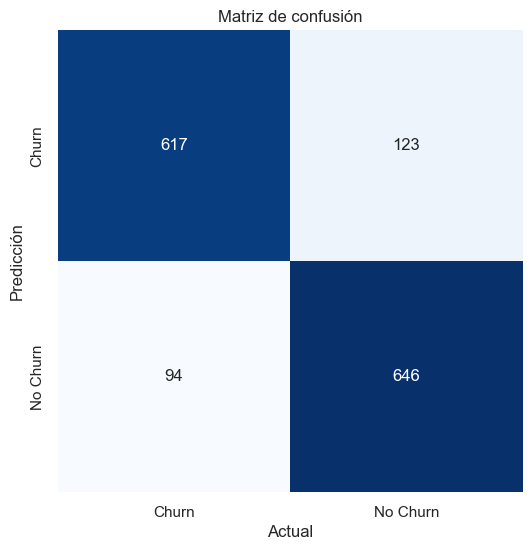

In [785]:
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Churn', 'No Churn'],
            yticklabels=['Churn', 'No Churn'])
plt.xlabel('Actual')
plt.ylabel('Predicción')
plt.title('Matriz de confusión')
plt.show()

- **613** observaciones fueron clasificadas correctamente como **Verdaderos Positivos (True Positives, TP)**.
- **127** observaciones fueron clasificadas como **Falsos Positivos (False Positives, FP)**.
- **96** observaciones fueron clasificadas como **Falsos Negativos (False Negatives, FN)**.
- **644** observaciones fueron clasificadas correctamente como **Verdaderos Negativos (True Negatives, TN)**.

### 5.3.2. Ajuste del Modelo 2 (Random Forest)

In [786]:
# Verificar los parámetros actuales del modelo
current_params = rfm.get_params()
current_params

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [787]:
# Ajuste de hiperparámetros del modelo Random Forest

# Definir las distribuciones de parámetros para el ajuste de hiperparámetros
param_grid = {
  'n_estimators': [20, 50, 100, 200, 300],
  'max_depth': [None, 10, 15, 20, 25],
  'min_samples_split': [2, 3, 4, 5, 6],
  'min_samples_leaf': [1, 2, 3, 4, 5],
  'class_weight': ['balanced', None],
  'max_features': ['auto', 'sqrt', 'log2'],
  'criterion': ['gini', 'entropy']
}

# Inicializar RandomizedSearchCV con el modelo RandomForestClassifier y las distribuciones de parámetros
random_search_rf = RandomizedSearchCV(estimator=rfm, param_distributions=param_grid, 
                                      scoring='accuracy', n_iter=150, random_state=42,
                                      cv=5, n_jobs=-1, verbose = 1)

# Entrenar el mejor estimador con los datos de entrenamiento
random_search_rf.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros encontrados
best_params = random_search_rf.best_params_

# Mostrar la exactitud promedio (mean accuracy) del mejor estimador
best_score = random_search_rf.best_score_

best_params

Fitting 5 folds for each of 150 candidates, totalling 750 fits


{'n_estimators': 200,
 'min_samples_split': 4,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': None,
 'criterion': 'entropy',
 'class_weight': 'balanced'}

In [788]:
# Mostrar la exactitud promedio (mean accuracy) del mejor estimador
best_score

np.float64(0.8498983345137191)

In [789]:
# Entrenar el modelo ajustado con los datos de entrenamiento
tuned_rf_model = random_search_rf.best_estimator_
tuned_rf_model.fit(X_train, y_train)

# Realizar las predicciones
random_search_rf_pred = tuned_rf_model.predict(X_test)
original_rf_model = rfm.predict(X_test)

In [790]:
# Calcular el reporte de clasificación
report = classification_report(y_test, original_rf_model, output_dict=True)
report_2 = classification_report(y_test, random_search_rf_pred, output_dict=True)

# Extraer las métricas de precisión (precision), sensibilidad (recall), puntuación F1 (F1-score) y exactitud (accuracy) para ambas clases
precision = ((report['1']['precision'] + report['0']['precision'])) / 2
recall = ((report['1']['recall'] + report['0']['recall'])) / 2
f1 = ((report['1']['f1-score'] + report['0']['f1-score'])) / 2

precision2 = ((report_2['1']['precision'] + report_2['0']['precision'])) / 2
recall2 = ((report_2['1']['recall'] + report_2['0']['recall'])) / 2
f12 = ((report_2['1']['f1-score'] + report_2['0']['f1-score'])) / 2

# Crear diccionarios para almacenar las métricas
metrics_original_Random_Forest = {
    'Total Precision': precision,
    'Total Recall': recall,
    'Total F1-Score': f1,
    'Accuracy': report['accuracy']
}

metrics_Tuned_Random_Forest = {
    'Total Precision': precision2,
    'Total Recall': recall2,
    'Total F1-Score': f12,
    'Accuracy': report_2['accuracy']
}

# Crear DataFrames a partir de los diccionarios de métricas
metrics_df_original = pd.DataFrame(metrics_original_Random_Forest, index=['Original Random Forest'])
metrics_df_tuned = pd.DataFrame(metrics_Tuned_Random_Forest, index=['Tuned Random Forest'])

# Concatenar los DataFrames verticalmente para combinar las métricas
combined_metrics_df = pd.concat([metrics_df_original, metrics_df_tuned])
combined_metrics_df

,Total Precision,Total Recall,Total F1-Score,Accuracy
Original Random Forest,0.856227,0.856081,0.856066,0.856081
Tuned Random Forest,0.862987,0.862838,0.862824,0.862838


In [791]:
# Construir la matriz de confusión del modelo ajustado
confusion_matrix_rf = confusion_matrix(y_test, random_search_rf_pred)
confusion_matrix_rf

array([[631, 109],
       [ 94, 646]])

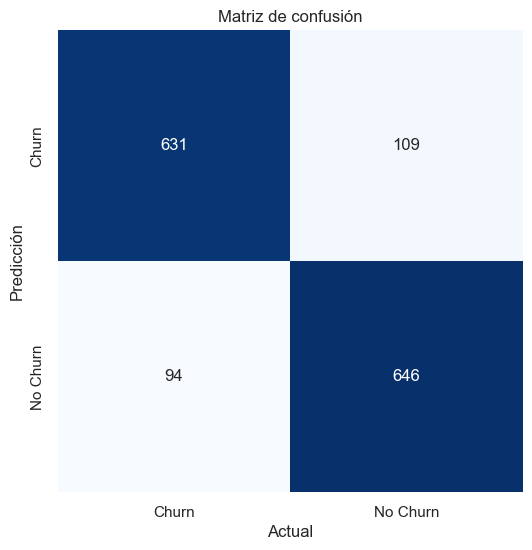

In [792]:
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Churn', 'No Churn'],
            yticklabels=['Churn', 'No Churn'])
plt.xlabel('Actual')
plt.ylabel('Predicción')
plt.title('Matriz de confusión')
plt.show()

- **630** observaciones fueron clasificadas correctamente como **Verdaderos Positivos (True Positives, TP)**.
- **110** observaciones fueron clasificadas como **Falsos Positivos (False Positives, FP)**.
- **97** observaciones fueron clasificadas como **Falsos Negativos (False Negatives, FN)**.
- **643** observaciones fueron clasificadas correctamente como **Verdaderos Negativos (True Negatives, TN)**.

### 5.3.3. Ajuste del Modelo 3 (Gradient Boosting)

In [793]:
# Verificar los parámetros actuales del modelo
current_params = gb.get_params()
current_params

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': 42,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [794]:
# Ajuste de hiperparámetros del modelo Gradient Boosting
param_grid = {
    'n_estimators': [None, 50, 100, 200, 300],
    'learning_rate': [None, 0.1, 0.2, 0.3, 0.4],
    'max_depth': [None, 3, 5, 7, 10],
    'subsample': [0.8, 0.9, 1.0, 1.1, 1.2],
    'min_samples_split': [2, 3, 5, 8, 10],
    'min_samples_leaf': [1, 2, 3, 4, 8],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['friedman_mse', 'mse', 'mae'],
    'min_impurity_decrease': [0.0, 0.1, 0.2],
    'ccp_alpha': [0.0, 0.1, 0.2]
}

# Inicializar RandomizedSearchCV
random_search_gb = RandomizedSearchCV(estimator=gb, param_distributions=param_grid, scoring='accuracy',
                                      cv=5,n_jobs=-1, n_iter=150, random_state=42, verbose = 2)

# Entrenar el mejor estimador con los datos de entrenamiento
random_search_gb.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros encontrados
best_params = random_search_gb.best_params_

# Mostrar la exactitud promedio (mean accuracy) del mejor estimador
best_score = random_search_gb.best_score_

best_params

Fitting 5 folds for each of 150 candidates, totalling 750 fits


{'subsample': 0.8,
 'n_estimators': 200,
 'min_samples_split': 8,
 'min_samples_leaf': 4,
 'min_impurity_decrease': 0.2,
 'max_features': None,
 'max_depth': 5,
 'learning_rate': 0.1,
 'criterion': 'friedman_mse',
 'ccp_alpha': 0.0}

In [795]:
# Mostrar la exactitud promedio (mean accuracy) del mejor estimador
best_score

np.float64(0.8507433574741267)

In [796]:
# Entrenar el modelo ajustado con los datos de entrenamiento
tuned_gb_model = random_search_gb.best_estimator_
tuned_gb_model.fit(X_train, y_train)

# Realizar las predicciones
random_search_gb_pred = tuned_gb_model.predict(X_test)
original_gb_model = gb.predict(X_test)

In [797]:
# Calcular el reporte de clasificación
report = classification_report(y_test, original_gb_model, output_dict=True)
report_2 = classification_report(y_test, random_search_gb_pred, output_dict=True)

# Extraer las métricas de precisión (precision), sensibilidad (recall), puntuación F1 (F1-score) y exactitud (accuracy) para ambas clases
precision = ((report['1']['precision'] + report['0']['precision'])) / 2
recall = ((report['1']['recall'] + report['0']['recall'])) / 2
f1 = ((report['1']['f1-score'] + report['0']['f1-score'])) / 2

precision2 = ((report_2['1']['precision'] + report_2['0']['precision'])) / 2
recall2 = ((report_2['1']['recall'] + report_2['0']['recall'])) / 2
f12 = ((report_2['1']['f1-score'] + report_2['0']['f1-score'])) / 2

# Crear DataFrames a partir de los diccionarios de métricas
metrics_original_GB = {
    'Total Precision': precision,
    'Total Recall': recall,
    'Total F1-Score': f1,
    'Accuracy': report['accuracy']
}

metrics_Tuned_GB = {
    'Total Precision': precision2,
    'Total Recall': recall2,
    'Total F1-Score': f12,
    'Accuracy': report_2['accuracy']
}

# Concatenar los DataFrames verticalmente para combinar las métricas
metrics_df_original = pd.DataFrame(metrics_original_GB, index=['Original Gradient Boosting'])
metrics_df_gb = pd.DataFrame(metrics_Tuned_GB, index=['Tuned Gradient Boosting'])

# Construir la matriz de confusión del modelo ajustado
combined_metrics_df = pd.concat([metrics_df_original, metrics_df_gb])
combined_metrics_df

,Total Precision,Total Recall,Total F1-Score,Accuracy
Original Gradient Boosting,0.843622,0.842568,0.842447,0.842568
Tuned Gradient Boosting,0.853611,0.853378,0.853354,0.853378


In [798]:
# construct the confusion matrix for tuned model
confusion_matrix_gb = confusion_matrix(y_test, random_search_gb_pred)
confusion_matrix_gb

array([[622, 118],
       [ 99, 641]])

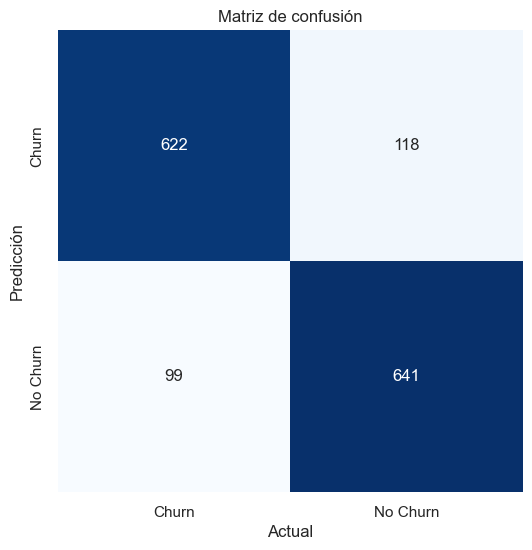

In [799]:
plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix_gb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Churn', 'No Churn'],
            yticklabels=['Churn', 'No Churn'])
plt.title('Matriz de confusión')
plt.xlabel('Actual')
plt.ylabel('Predicción')
plt.show()

- **614** observaciones fueron clasificadas correctamente como **Verdaderos Positivos (True Positives, TP)**.
- **126** observaciones fueron clasificadas como **Falsos Positivos (False Positives, FP)**.
- **98** observaciones fueron clasificadas como **Falsos Negativos (False Negatives, FN)**.
- **642** observaciones fueron clasificadas correctamente como **Verdaderos Negativos (True Negatives (TN)**.

- Tras realizar el ajuste de hiperparámetros en los tres modelos, el modelo **Random Forest** obtuvo el mejor desempeño, alcanzando una **exactitud (accuracy)** de **0.860135**, equivalente aproximadamente al **86 %**. Por ello, este modelo será seleccionado para su almacenamiento y posteriormente utilizado para realizar predicciones sobre datos no observados.

## 5.4. Exportación de los Componentes Principales

En esta sección se **exportarán** los principales objetos utilizados en el flujo de trabajo de *Machine Learning*, los cuales serán necesarios para el desarrollo e implementación de una aplicación. Entre ellos se incluyen el **codificador (Encoder)**, el **escalador (Scaler)**, el **ColumnTransformer**, el **modelo entrenado**, el **Pipeline**, entre otros.

In [800]:
destination = "Toolkit"

# Crear un directorio si no existe
if not os.path.exists(destination):
    os.makedirs(destination)

# Crear un diccionario para almacenar los objetos y sus respectivos nombres de archivo
models ={
    "Random Forest Classifier":tuned_rf_model,
}

#Loop through the model and save using joblib.dump()
for name,model in models.items():
    file_path =os.path.join(destination,f"{name}.joblib")
    joblib.dump(model,file_path)

## 5.5. Predicciones Futuras

### Preprocesamiento del conjunto de datos de prueba

In [801]:
test = pd.read_csv(r"data\processed\Test_Data.csv")
test.info()
test.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1997 entries, 0 to 1996
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1997 non-null   object 
 1   gender            1997 non-null   object 
 2   SeniorCitizen     1997 non-null   object 
 3   Partner           1997 non-null   object 
 4   Dependents        1997 non-null   object 
 5   tenure            1997 non-null   int64  
 6   PhoneService      1997 non-null   object 
 7   MultipleLines     1997 non-null   object 
 8   InternetService   1997 non-null   object 
 9   OnlineSecurity    1997 non-null   object 
 10  OnlineBackup      1997 non-null   object 
 11  DeviceProtection  1997 non-null   object 
 12  TechSupport       1997 non-null   object 
 13  StreamingTV       1997 non-null   object 
 14  StreamingMovies   1997 non-null   object 
 15  Contract          1997 non-null   object 
 16  PaperlessBilling  1997 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7613-LLQFO,Male,No,No,No,12,Si,Si,Fiber optic,No,No,No,No,Si,No,Month-to-month,Si,Electronic check,84.45,1059.55
1,4568-TTZRT,Male,No,No,No,9,Si,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.40,181.80
2,9513-DXHDA,Male,No,No,No,27,Si,No,DSL,Si,No,Si,Si,Si,Si,One year,No,Electronic check,81.70,2212.55
3,2640-PMGFL,Male,No,No,Si,27,Si,Si,Fiber optic,No,No,No,Si,No,No,Month-to-month,Si,Electronic check,79.50,2180.55
4,3801-HMYNL,Male,No,Si,Si,1,Si,No,Fiber optic,No,No,No,No,Si,Si,Month-to-month,No,Mailed check,89.15,89.15


In [802]:
# Almacenar la columna CustomerID antes de eliminarla del conjunto de datos de prueba
customerID = test['customerID']

# Eliminar columnas del conjunto de datos de prueba
test.drop(columns=['gender','PhoneService', 'MultipleLines', 'customerID'],axis = 1, inplace=True)

In [803]:
# Codificar las variables categóricas mediante One-Hot Encoder
cat_cols = ['SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

transformer = make_column_transformer(
    (OneHotEncoder(sparse_output=False), cat_cols)
)

transformed_data = transformer.fit_transform(test[cat_cols])

# Transformar nuevamente el resultado en un DataFrame
transformed_df = pd.DataFrame(transformed_data, columns=transformer.get_feature_names_out())

# La codificación One-Hot eliminó el índice; se restaura para conservar la correspondencia de los registros
transformed_df.index = test.index

# Unir las tablas
test = pd.concat([test, transformed_df], axis=1)

# Eliminar las columnas categóricas originales
test.drop(cat_cols, axis=1, inplace=True)

test.head()

,tenure,MonthlyCharges,TotalCharges,onehotencoder__SeniorCitizen_No,onehotencoder__SeniorCitizen_Si,onehotencoder__Partner_No,onehotencoder__Partner_Si,onehotencoder__Dependents_No,onehotencoder__Dependents_Si,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__OnlineSecurity_No,onehotencoder__OnlineSecurity_No internet service,onehotencoder__OnlineSecurity_Si,onehotencoder__OnlineBackup_No,onehotencoder__OnlineBackup_No internet service,onehotencoder__OnlineBackup_Si,onehotencoder__DeviceProtection_No,onehotencoder__DeviceProtection_No internet service,onehotencoder__DeviceProtection_Si,onehotencoder__TechSupport_No,onehotencoder__TechSupport_No internet service,onehotencoder__TechSupport_Si,onehotencoder__StreamingTV_No,onehotencoder__StreamingTV_No internet service,onehotencoder__StreamingTV_Si,onehotencoder__StreamingMovies_No,onehotencoder__StreamingMovies_No internet service,onehotencoder__StreamingMovies_Si,onehotencoder__Contract_Month-to-month,onehotencoder__Contract_One year,onehotencoder__Contract_Two year,onehotencoder__PaperlessBilling_No,onehotencoder__PaperlessBilling_Si,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check
0,12,84.45,1059.55,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,9,20.40,181.80,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,27,81.70,2212.55,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,27,79.50,2180.55,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,1,89.15,89.15,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [804]:
test.columns =test.columns.str.replace('onehotencoder__', '')

In [805]:
# Escalar las variables numéricas
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

test_scaled = scaler.fit_transform(test[cols])

# Crear nuevos DataFrames con los valores escalados
test_scaled_df = pd.DataFrame(test_scaled, columns=cols, index=test.index)

# Eliminar las columnas originales sin escalar
test.drop(cols, axis=1, inplace=True)

# Concatenar las columnas escaladas con los DataFrames originales
test = pd.concat([test, test_scaled_df], axis=1)

test.head()

,SeniorCitizen_No,SeniorCitizen_Si,Partner_No,Partner_Si,Dependents_No,Dependents_Si,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Si,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Si,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Si,TechSupport_No,TechSupport_No internet service,TechSupport_Si,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Si,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Si,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Si,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure,MonthlyCharges,TotalCharges
0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-0.808517,0.679346,-0.520729
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-0.930399,-1.448044,-0.909246
2,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.199108,0.588006,-0.010377
3,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-0.199108,0.514934,-0.024542
4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-1.255417,0.835454,-0.950256


### Predicciones

In [806]:
# Cargar el modelo
loaded_model = load(r"Toolkit\Random Forest Classifier.joblib")

# Predecir las etiquetas del conjunto de datos de prueba preprocesado utilizando el modelo entrenado
predictions = loaded_model.predict(test)

# Crear un DataFrame para almacenar las predicciones
data_predictions = pd.DataFrame(predictions, columns=['Predicted_Label'])

data_predictions['customer_id'] = customerID.reset_index(drop=True)

data_predictions.set_index('customer_id', inplace=True)

data_predictions.head()

,Predicted_Label
customer_id,
7613-LLQFO,1
4568-TTZRT,0
9513-DXHDA,0
2640-PMGFL,0
3801-HMYNL,1


In [807]:
data_predictions.to_csv(r"data\processed\data_predictions.csv", index=True)

In [808]:
# Mapear las predicciones numéricas a las categorías 'No' y 'Sí'
data_predictions['Predicted_Label'] = data_predictions['Predicted_Label'].map({0: 'No', 1: 'Yes'})

# data_predictions['customerID'] = customerID
data_predictions.value_counts()

Predicted_Label
No                 1417
Yes                 580
Name: count, dtype: int64

Las predicciones dieron como resultado **1,427** casos clasificados como **No Deserción (Not Churn)** y **570** casos clasificados como **Deserción (Churn)**.

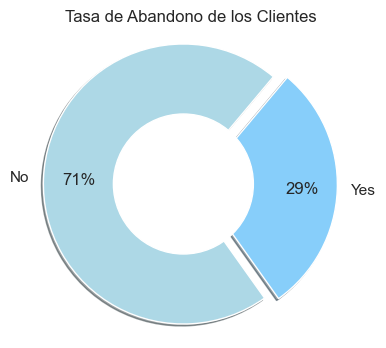

In [809]:
label_counts = data_predictions['Predicted_Label'].value_counts()

# Convertir los conteos a valores numéricos
count_values = label_counts.values
 
# Crear un gráfico circular utilizando pyplot para visualizar la tasa de deserción de clientes (churn)
plt.figure(figsize=(4, 4))

plt.pie(count_values, labels=label_counts.index, colors=['LightBlue','LightSkyBlue'], startangle=50, shadow=True, radius=2,
     explode=(0,0.2),autopct='%1.0f%%', pctdistance=0.75 ,  )
Circle=plt.Circle((0,0), 1, color='white')
c= plt.gcf()

c.gca().add_artist(Circle)
# La relación de aspecto igual garantiza que el gráfico circular se dibuje como un círculo perfecto
plt.axis('equal')
plt.title('Tasa de Abandono de los Clientes')
plt.show()

# 6. Conclusión

- El **tiempo de permanencia del cliente en la empresa** (*tenure*) y el **tipo de contrato** (*contract*) son las variables con mayor importancia y presentan una fuerte relación con la deserción de clientes (*churn*).

- **Vodafone** debería fortalecer la experiencia del cliente durante sus primeros meses en la empresa. El análisis muestra que, entre los **5 y 10 primeros meses**, la tasa de deserción es considerablemente mayor, lo que sugiere que la experiencia inicial del cliente es determinante. Mejorar los procesos de incorporación (*onboarding*), la calidad del servicio y la atención de las inquietudes de los clientes mediante un soporte técnico oportuno puede incrementar su satisfacción y fidelidad.

- **Vodafone** debería fomentar la contratación de planes de largo plazo. Los resultados indican que los clientes con contratos **mes a mes** presentan una tasa de deserción significativamente mayor que aquellos con contratos de **uno o dos años**. Incentivar la adopción de contratos de mayor duración mediante beneficios, promociones y un mejor soporte técnico puede contribuir a reducir la deserción y fortalecer el compromiso de los clientes con la empresa.

- La **optimización de hiperparámetros** (*hyperparameter tuning*) no siempre produce mejoras sustanciales en el desempeño de los modelos.

* Con una partición de **80 % para entrenamiento** y **20 % para evaluación**, el modelo de **Bosque Aleatorio (Random Forest)** alcanzó una **exactitud (accuracy) cercana al 86 %** después de la optimización de hiperparámetros.

- Los **métodos de ensamble (Ensemble Methods)** muestran un mejor desempeño en problemas de clasificación en comparación con los clasificadores individuales.